# COMPARISON OF MOCAP VS CAMERA , MOCAP VS ENCODER , CAMERA VS ENCODER 

In [52]:
# Cell 1
import importlib.util
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
import cv2
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import toml
import matplotlib.gridspec as gridspec
from math import sqrt
import warnings
from pathlib import Path
from scipy.signal import correlate
warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## Step 1: Load Multiple Rigid body file

In [53]:
# Cell 2
try:
    # ── locate notebook & repo root ───────────────────────────────────────────
    try:
        _nb_file = Path(globals()['__vsc_ipynb_file__']).resolve()
        _nb_dir  = _nb_file.parent
    except KeyError:
        _nb_dir = Path.cwd()

    repo_root = _nb_dir
    for candidate in [_nb_dir, *_nb_dir.parents]:
        if (candidate / 'vaideesh').exists() or (candidate / '.venv').exists():
            repo_root = candidate
            break

    print(f'Repo root : {repo_root}')

    # ── load multiple_rigid_body module ───────────────────────────────────────
    _script_path = repo_root / 'vaideesh' / 'Analysis' / 'multiple_rigid_body.py'
    assert _script_path.exists(), f'Script not found: {_script_path}'

    _script_dir = str(_script_path.parent)
    if _script_dir not in sys.path:
        sys.path.insert(0, _script_dir)

    spec = importlib.util.spec_from_file_location('multiple_rigid_body', _script_path)
    mrb  = importlib.util.module_from_spec(spec)
    sys.modules['multiple_rigid_body'] = mrb
    spec.loader.exec_module(mrb)

    # ── bring helper functions into notebook namespace ────────────────────────
    add_datetime_col_3rb   = mrb.add_datetime_col_3rb
    trunkate_3_dfs         = mrb.trunkate_3_dfs
    trunkate_dfs           = mrb.trunkate_dfs
    get_rb_pos_cols        = mrb.get_rb_pos_cols
    get_rb_rot_cols        = mrb.get_rb_rot_cols
    get_rb_marker_name_3rb = mrb.get_rb_marker_name_3rb

    # ════════════════════════════════════════════════════════════════════════
    # load_csv_auto
    # ════════════════════════════════════════════════════════════════════════
    def load_csv_auto(csv_path, mrb, truncate=True):
        csv_path = str(csv_path)

        _raw      = pd.read_csv(csv_path, skiprows=2, header=None, dtype=str)
        _type_row = _raw.iloc[0].fillna('').str.strip().tolist()
        _name_row = _raw.iloc[1].fillna('').str.strip().tolist()

        detected = []
        for t, name in zip(_type_row, _name_row):          # ← fixed: n → name
            if t == 'Rigid Body' and name and name not in detected:
                detected.append(name)

        n_bodies = len(detected)                            # ← fixed: n → n_bodies
        print(f'  Detected {n_bodies} rigid bod{"y" if n_bodies == 1 else "ies"}: {detected}')

        if n_bodies not in (2, 3):
            raise ValueError(
                f'load_csv_auto: found {n_bodies} rigid bodies {detected} in\n  {csv_path}\n'
                f'read_3_rigid_body_csv supports 2 or 3 bodies only.'
            )

        rb_dfs, st_time = mrb.read_3_rigid_body_csv(csv_path, rb_names=detected)
        rb_dfs = mrb.add_datetime_col_3rb(rb_dfs, st_time)

        if truncate:
            names = list(rb_dfs.keys())
            if n_bodies == 3:
                rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]] = mrb.trunkate_3_dfs(
                    rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]],
                    display_print=True,
                )
            else:
                rb_dfs[names[0]], rb_dfs[names[1]] = mrb.trunkate_dfs(
                    rb_dfs[names[0]], rb_dfs[names[1]],
                    display_print=True,
                )

        return rb_dfs, st_time, detected

    # ── File paths ────────────────────────────────────────────────────────────
    TABLE_FILE = mrb.FILE
    NOARK_FILE = "E:\\Ragav\\MS Bio Engineering\\NOARK_backbone\\mocap_recordings\\mocap_recordings_may_4\\linear_fast_t1_may_4.csv"

    print(f'Loading TABLE file (geometry only): {TABLE_FILE}')
    table_rb_dfs, table_st_time, table_bodies = load_csv_auto(TABLE_FILE, mrb)

    for required in ('tframe', 'table'):
        if required not in table_rb_dfs:                   # ← fixed: assert → if/raise
            raise ValueError(
                f'"{required}" not found in TABLE file. '
                f'Detected bodies: {table_bodies}'
            )

    print(f'\nLoading NOARK file (experiment data): {NOARK_FILE}')
    noark_rb_dfs, noark_st_time, noark_bodies = load_csv_auto(NOARK_FILE, mrb)

    # ── Merge ─────────────────────────────────────────────────────────────────
    rb_dfs = {
        'tframe': table_rb_dfs['tframe'],
        'table' : table_rb_dfs['table'],
    }
    for k, v in noark_rb_dfs.items():
        if k not in ('tframe', 'table'):
            rb_dfs[k] = v

    print(f'\nCombined rb_dfs keys : {list(rb_dfs.keys())}')
    print(f'Script loaded        : {_script_path}')
    print(f'TABLE st_time (geometry only) : {table_st_time}')
    print(f'NOARK st_time (time alignment): {noark_st_time}')

    # ── Final sanity checks ───────────────────────────────────────────────────
    if 'tframe' not in rb_dfs:
        raise ValueError(f"Missing 'tframe'. Keys: {list(rb_dfs.keys())}")
    if 'table' not in rb_dfs:
        raise ValueError(f"Missing 'table'. Keys: {list(rb_dfs.keys())}")
    if len(rb_dfs) < 3:
        raise ValueError(f"Expected ≥3 bodies after merge, got: {list(rb_dfs.keys())}")

    noark_key = [k for k in rb_dfs if k not in ('tframe', 'table')][0]
    print("\n✅ Cell 2 passed all checks")
    print(f"   rb_dfs keys : {list(rb_dfs.keys())}")
    print(f"   noark rows  : {rb_dfs[noark_key].shape[0]}")

except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
except ValueError as e:
    print(f"❌ Value error: {e}")
except KeyError as e:
    print(f"❌ Missing key: {e}")
except Exception as e:
    print(f"❌ Unexpected error: {type(e).__name__}: {e}")
    raise

Repo root : E:\Ragav\MS Bio Engineering\NOARK_backbone
Loading TABLE file (geometry only): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_recordings\mocap_recordings_may_4\table_frame_may_4.csv
  Detected 2 rigid bodies: ['table', 'tframe']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 162

Loading NOARK file (experiment data): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_recordings\mocap_recordings_may_4\linear_fast_t1_may_4.csv
  Detected 2 rigid bodies: ['table', 'noark']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 4220

Combined rb_dfs keys : ['tframe', 'table', 'noark']
Script loaded        : E:\Ragav\MS Bio Engineering\NOARK_backbone\vaideesh\Analysis\multiple_rigid_body.py
TABLE st_time (geometry only) : 2026-05-04 12:28:09.310000
NOARK st_time (time alignment): 2026-05-04 12:35:52.446000

✅ Cell 2 passed all checks
   rb_dfs keys : ['tframe', 'table', 'noark']
   noark rows  : 4221


## Verify Data frames

In [54]:
# Cell 3
print('DataFrames from multiple_rigid_body.py:')
print(f'{"Body":<10}  {"Shape":<15}  {"Has time col"}')
print('-' * 40)
for name, df in rb_dfs.items():
    has_time = 'time' in df.columns
    print(f'{name:<10}  {str(df.shape):<15}  {has_time}')

print('\nNaN rows per body:')
for name, df in rb_dfs.items():
    nan_rows = df.isna().any(axis=1).sum()
    print(f'  {name}: {nan_rows} NaN rows out of {len(df)}')

DataFrames from multiple_rigid_body.py:
Body        Shape            Has time col
----------------------------------------
tframe      (163, 27)        True
table       (163, 35)        True
noark       (4221, 27)       True

NaN rows per body:
  tframe: 1 NaN rows out of 163
  table: 1 NaN rows out of 163
  noark: 1 NaN rows out of 4221


## Inspect RAW DATAFRAMES

In [55]:
# # Cell 4
# # Tframe is the most critical since it defines the coordinate system, so we check it first.
# print('── tframe ──')
# display(rb_dfs['tframe'].head(3))

In [56]:
# # Cell 5
# # NOARK body is next most critical since it contains the data we want to compare against, so we check it next.
# noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
# print(f'── {noark_key} ──')
# display(rb_dfs[noark_key].head(3))

In [57]:
# # Cell 6
# #TABLE body is least critical since it's only used for time alignment, so we check it last. 
# print('── table ──')
# display(rb_dfs['table'].head(30))

## Cell 5 — Define `transform_to_tframe()`

**Coordinate frame construction (per frame, from mocap marker positions):**

| Step | Detail |
|---|---|
| Origin | `tframe_marker_1` position in mocap frame |
| X axis | `tframe_marker_2 − origin`, normalised |
| Y axis | `tframe_marker_4 − origin`, Gram-Schmidt orthogonalised then normalised |
| Z axis | `X × Y` (right-handed) |
| Translation reference | `tframe_marker_1` → becomes **(0, 0, 0)** in table frame |

**Transform formula:** `p_table = R_mocap2table.T @ (p_mocap − t_mocap)`  
where `R_mocap2table` columns are `[vxnorm, vynorm, vznorm]` and `t_mocap = tvec(tframe_marker_3)`.

**Units:** Motive exports positions in **metres** — no conversion needed.  
**Column suffix `_m`** makes the unit explicit in every position column.

In [58]:
# Cell 7
# ── RECORDING-SPECIFIC CONFIG ─────────────────────────────────────────────────
# Update these three lines for each new recording using your notes sheet.
#
#   ORIGIN_MARKER : tframe marker that becomes (0,0,0)       → notes: tframe_marker_2
#   X_MARKER      : tframe marker that defines the +X axis    → notes: tframe_marker_1
#   Y_MARKER      : tframe marker that defines the +Y axis    → notes: tframe_marker_3
#   NOARK_MARKER  : noark rigid-body marker index to track    → notes: noark_marker_1
# ─────────────────────────────────────────────────────────────────────────────
ORIGIN_MARKER = 3   # tframe_marker_2  (origin)
X_MARKER      = 4   # tframe_marker_1  (defines +X direction)
Y_MARKER      = 2   # tframe_marker_3  (defines +Y direction)
NOARK_MARKER  = 3   # noark_marker_1   (the NOARK point to track)

def transform_to_tframe(rb_dfs,
                        origin_marker=ORIGIN_MARKER,
                        x_marker=X_MARKER,
                        y_marker=Y_MARKER,
                        noark_marker=NOARK_MARKER):
    tframe_df = rb_dfs['tframe'].copy()
    noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
    noark_df  = rb_dfs[noark_key].copy()
    print(f'Using noark key: "{noark_key}"')
    print(f'tframe: origin=m{origin_marker}, X=m{x_marker}-m{origin_marker}, Y=m{y_marker}-m{origin_marker}')
    print(f'noark : tracking marker m{noark_marker}')
    table_df  = rb_dfs['table'].copy()

    def _mean_marker(df, label, m_idx):
        cols = [f'{label}_marker_m{m_idx}_x',
                f'{label}_marker_m{m_idx}_y',
                f'{label}_marker_m{m_idx}_z']
        return df[cols].mean().values.astype(float)

    # ── Build a SINGLE fixed coordinate frame from mean tframe marker positions ──
    org = _mean_marker(tframe_df, 'tframe', origin_marker)  # origin
    px  = _mean_marker(tframe_df, 'tframe', x_marker)       # point along +X
    py  = _mean_marker(tframe_df, 'tframe', y_marker)       # point along +Y

    v1 = px - org   # raw X-axis vector
    v2 = py - org   # raw Y-axis vector (not yet orthogonalised)

    # Gram-Schmidt orthonormalisation
    vxnorm = v1 / np.linalg.norm(v1)
    vycap  = v2 - np.dot(v2, vxnorm) * vxnorm
    vynorm = vycap / np.linalg.norm(vycap)
    vznorm = np.cross(vxnorm, vynorm)   # BUG FIX: was cross(vynorm, vxnorm) → left-handed!

    R_mat = np.stack([vxnorm, vynorm, vznorm], axis=-1)  # (3,3) — fixed
    t_vec = org                                           # origin in mocap frame

    # ── Helper: transform any (N,3) array into table frame ───────────────────
    def pos_to_tframe(p_mocap):
        return (R_mat.T @ (p_mocap - t_vec).T).T          # (N, 3)

    # ── noark ─────────────────────────────────────────────────────────────────
    noark_result = pd.DataFrame({
        'frame'  : noark_df['frame'].values,
        'seconds': noark_df['seconds'].values,
        'time'   : noark_df['time'].values,
    })

    col_suffix = f'm{noark_marker}'
    out_suffix = f'noark_m{noark_marker}'
    try:
        p = noark_df[[f'{noark_key}_marker_{col_suffix}_x',
                      f'{noark_key}_marker_{col_suffix}_y',
                      f'{noark_key}_marker_{col_suffix}_z']].values.astype(float)
        p_tf = pos_to_tframe(p)
        noark_result[f'{out_suffix}_tf_x_m'] = p_tf[:, 0]
        noark_result[f'{out_suffix}_tf_y_m'] = p_tf[:, 1]
        noark_result[f'{out_suffix}_tf_z_m'] = p_tf[:, 2]
    except KeyError:
        print(f'  ERROR: noark marker m{noark_marker} columns not found!')
        print(f'  Available noark cols: {[c for c in noark_df.columns if "marker" in c]}')

    # ── table ─────────────────────────────────────────────────────────────────
    table_result = pd.DataFrame({
        'frame'  : table_df['frame'].values,
        'seconds': table_df['seconds'].values,
        'time'   : table_df['time'].values,
    })

    for i in range(1, 7):
        try:
            p = table_df[[f'table_marker_m{i}_x',
                           f'table_marker_m{i}_y',
                           f'table_marker_m{i}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            table_result[f'table_m{i}_tf_x_m'] = p_tf[:, 0]
            table_result[f'table_m{i}_tf_y_m'] = p_tf[:, 1]
            table_result[f'table_m{i}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            pass

    return {
        'noark_in_tframe' : noark_result.reset_index(drop=True),
        'table_in_tframe' : table_result.reset_index(drop=True),
        '_R_mat'          : R_mat,
        '_t_vec'          : t_vec,
        '_noark_marker'   : noark_marker,
    }


## RUN THE TRANSFORMATION

In [59]:
# Cell 8
tframe_dfs = transform_to_tframe(rb_dfs)

print('noark_in_tframe shape :', tframe_dfs['noark_in_tframe'].shape)
print('table_in_tframe shape :', tframe_dfs['table_in_tframe'].shape)
print('\nnoark_in_tframe columns:')
print(tframe_dfs['noark_in_tframe'].columns.tolist())
print('\ntable_in_tframe columns:')
print(tframe_dfs['table_in_tframe'].columns.tolist())

Using noark key: "noark"
tframe: origin=m3, X=m4-m3, Y=m2-m3
noark : tracking marker m3
noark_in_tframe shape : (4221, 6)
table_in_tframe shape : (163, 21)

noark_in_tframe columns:
['frame', 'seconds', 'time', 'noark_m3_tf_x_m', 'noark_m3_tf_y_m', 'noark_m3_tf_z_m']

table_in_tframe columns:
['frame', 'seconds', 'time', 'table_m1_tf_x_m', 'table_m1_tf_y_m', 'table_m1_tf_z_m', 'table_m2_tf_x_m', 'table_m2_tf_y_m', 'table_m2_tf_z_m', 'table_m3_tf_x_m', 'table_m3_tf_y_m', 'table_m3_tf_z_m', 'table_m4_tf_x_m', 'table_m4_tf_y_m', 'table_m4_tf_z_m', 'table_m5_tf_x_m', 'table_m5_tf_y_m', 'table_m5_tf_z_m', 'table_m6_tf_x_m', 'table_m6_tf_y_m', 'table_m6_tf_z_m']


## INSPECT TRANSFORMED DATAFRAMES

In [60]:
# # Cell 9
# print('── noark in tframe ──')
# display(tframe_dfs['noark_in_tframe'].head())

In [61]:
# # Cell 10
# print('── table in tframe ──')
# display(tframe_dfs['table_in_tframe'].head())

## SANITY CHECKS

In [62]:
# Cell 11
# ── Sanity checks — fixed (3,3) rotation matrix ──────────────────────────────
R_mat = tframe_dfs['_R_mat']           # (3,3)
t_vec = tframe_dfs['_t_vec']           # (3,) — tframe_marker_2 = origin

def _chk(label, val, tol, unit=''):
    print(f'  {label:<46} {val:.2e} {unit}  →  {"PASS ✓" if val < tol else "FAIL ✗"}')

print('Sanity checks')
print('─' * 62)

# Check 1: origin (t_vec = m1) maps to (0,0,0)
p_origin = R_mat.T @ (t_vec - t_vec)
_chk('Check 1  origin  → (0,0,0)', np.max(np.abs(p_origin)), 1e-10, 'm')

# Check 2: R columns are unit vectors
col_norms = np.linalg.norm(R_mat, axis=0)
_chk('Check 2  R columns are unit vectors', np.max(np.abs(col_norms - 1.0)), 1e-6)

# Check 3: R.T @ R = I
RtR = R_mat.T @ R_mat
_chk('Check 3  R.T @ R = I  (orthogonality)', np.max(np.abs(RtR - np.eye(3))), 1e-6)

# Check 4: det(R) = +1
det = np.linalg.det(R_mat)
print(f'  {"Check 4  det(R) = +1  (right-handed)":<46} det = {det:.8f}  →  {"PASS ✓" if abs(det-1.0)<1e-6 else "FAIL ✗"}')

print(f'\nR_mat (columns = X/Y/Z axes of table frame in mocap):\n{np.round(R_mat, 6)}')
print(f'\nt_vec (table origin = tframe in mocap, m): {np.round(t_vec, 6)}')

Sanity checks
──────────────────────────────────────────────────────────────
  Check 1  origin  → (0,0,0)                     0.00e+00 m  →  PASS ✓
  Check 2  R columns are unit vectors            1.11e-16   →  PASS ✓
  Check 3  R.T @ R = I  (orthogonality)          1.11e-16   →  PASS ✓
  Check 4  det(R) = +1  (right-handed)           det = 1.00000000  →  PASS ✓

R_mat (columns = X/Y/Z axes of table frame in mocap):
[[-0.999819  0.018641  0.003767]
 [ 0.018528  0.999435 -0.028028]
 [-0.004288 -0.027953 -0.9996  ]]

t_vec (table origin = tframe in mocap, m): [-2.55670e-01 -1.83000e-04  2.27819e-01]


## NOARK POSITION IN TABLE FRAME 

In [63]:
# Cell 12 — noark marker position in table frame
_nm = tframe_dfs['_noark_marker']   # e.g. 1
df_n = tframe_dfs['noark_in_tframe']
print(f'noark Marker {_nm} — position in tframe coordinate system (metres)')
_xcol = f'noark_m{_nm}_tf_x_m'
_ycol = f'noark_m{_nm}_tf_y_m'
_zcol = f'noark_m{_nm}_tf_z_m'
print(df_n[['frame','seconds', _xcol, _ycol, _zcol]].to_string(index=False))
print('\nSummary statistics (metres):')
display(df_n[[_xcol, _ycol, _zcol]].describe().round(6))


noark Marker 3 — position in tframe coordinate system (metres)
 frame  seconds  noark_m3_tf_x_m  noark_m3_tf_y_m  noark_m3_tf_z_m
     0     0.00        -0.172194         0.197872        -0.211032
     1     0.01        -0.172188         0.197906        -0.211047
     2     0.02        -0.172200         0.197857        -0.211039
     3     0.03        -0.172161         0.197879        -0.211025
     4     0.04        -0.172185         0.197977        -0.211083
     5     0.05        -0.172168         0.197879        -0.211024
     6     0.06              NaN              NaN              NaN
     7     0.07        -0.172192         0.197861        -0.211034
     8     0.08        -0.172168         0.197887        -0.211024
     9     0.09        -0.172167         0.197857        -0.211024
    10     0.10        -0.172165         0.197891        -0.211026
    11     0.11        -0.172161         0.197880        -0.211019
    12     0.12        -0.172186         0.197860        -0.211033

,noark_m3_tf_x_m,noark_m3_tf_y_m,noark_m3_tf_z_m
count,4220.000000,4220.000000,4220.000000
mean,-0.062147,0.196372,-0.262140
std,0.249113,0.001100,0.031828
min,-0.354991,0.193621,-0.351263
25%,-0.296714,0.195494,-0.285204
50%,-0.172296,0.196318,-0.263040
75%,0.207477,0.197379,-0.239833
max,0.375848,0.198830,-0.209989


## TABLE MARKER POSITION P1-P4 AND MOTOR POSITION M1 AND M2

In [64]:
# Cell 13
df_t = tframe_dfs['table_in_tframe']
for i in range(1, 7):
    cols = [f'table_m{i}_tf_x_m', f'table_m{i}_tf_y_m', f'table_m{i}_tf_z_m']
    # print(f'\ntable Marker {i} — position in tframe coordinate system (metres)')
    # print(df_t[['frame','seconds'] + cols].to_string(index=False))
    # print(f'\nSummary statistics — Marker {i} (metres):')
    # display(df_t[cols].describe().round(6))

## XY POSITION OF ALL TABLE MARKERS

In [65]:
# Cell 14
import numpy as np

df_t = tframe_dfs['table_in_tframe'].copy()

print('Mean positions of all table markers in table frame (cm)')
print(f'  {"Marker":<12}  {"X (cm)":>10}  {"Y (cm)":>10}  {"Z (cm)":>10}')
print('-' * 50)
marker_xy = {}
for mid in range(1, 7):
    xc = f'table_m{mid}_tf_x_m'
    yc = f'table_m{mid}_tf_y_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns:
        x = df_t[xc].mean() * 100
        y = df_t[yc].mean() * 100
        z = df_t[zc].mean() * 100
        marker_xy[mid] = (x, y)
        print(f'  table_m{mid:<6}    {x:>10.2f}  {y:>10.2f}  {z:>10.2f}')
    else:
        print(f'  table_m{mid:<6}    NOT FOUND')

Mean positions of all table markers in table frame (cm)
  Marker            X (cm)      Y (cm)      Z (cm)
--------------------------------------------------
  table_m1              -7.24        9.69      -69.09
  table_m2              49.11        5.90      -76.35
  table_m3             -49.42        5.72      -76.25
  table_m4               5.66        9.78      -68.90
  table_m5              49.02        7.36       -2.01
  table_m6             -49.13        7.56       -1.99


## NOARK : X and Z Position Over Time

Plots X and Z position in the table coordinate frame over time.

- **Top subplot**: X position (left ↔ right) over time
- **Bottom subplot**: Z position (up ↕ down) over time
- Axes in **cm** for readability.

Plotting NOARK marker: m3


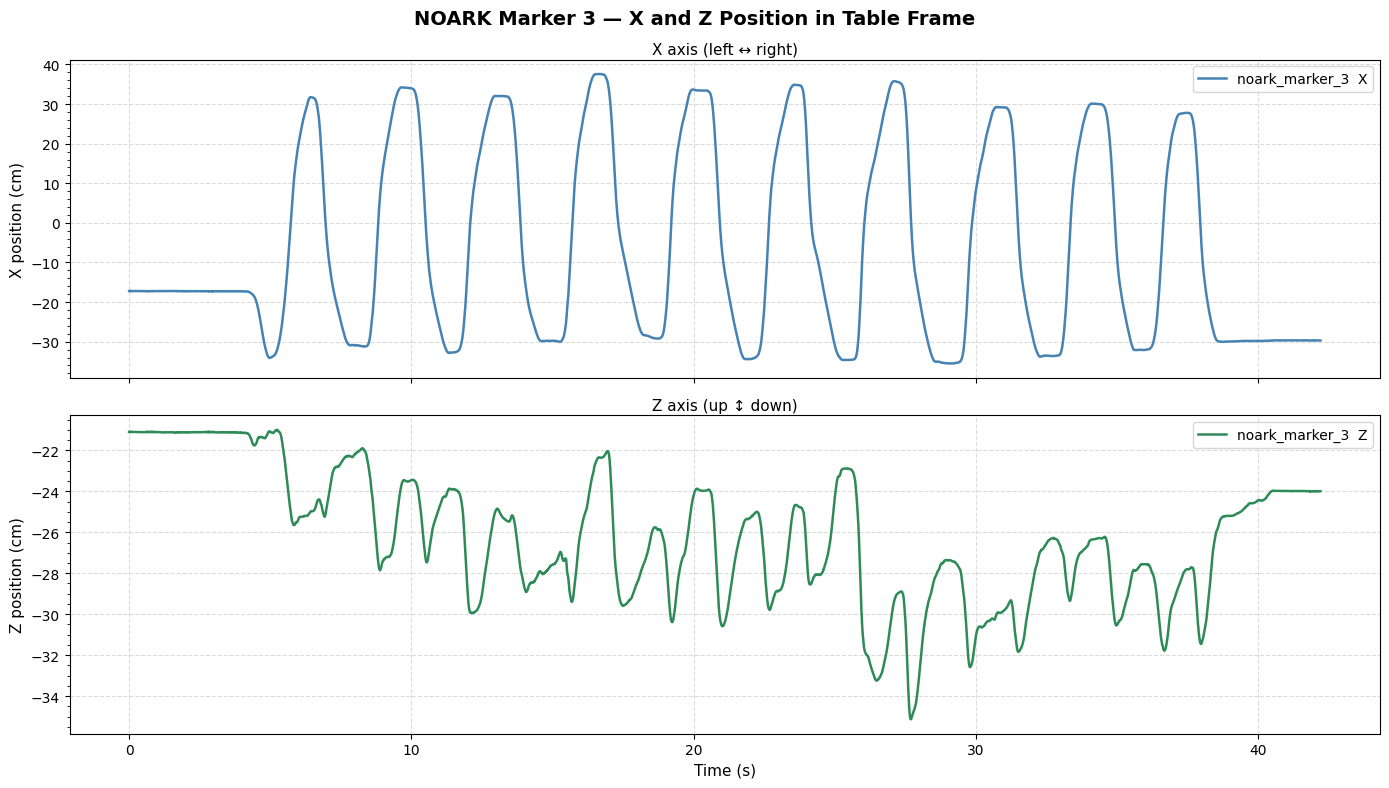

X range: nan → nan cm  (span nan cm)
Z range: nan → nan cm  (span nan cm)
Duration: 42.20 s  (4221 frames)


In [66]:
# Cell 15
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
_nm  = tframe_dfs['_noark_marker']
PLOT_MARKER = f'm{_nm}'

assert f'noark_{PLOT_MARKER}_tf_x_m' in df_n.columns, (
    f'noark_{PLOT_MARKER}_tf_x_m not found. Available: {df_n.columns.tolist()}'
)
print(f'Plotting NOARK marker: {PLOT_MARKER}')

cam_t = df_n['seconds'].values
cam_x = df_n[f'noark_{PLOT_MARKER}_tf_x_m'].values * 100.0   # m → cm
cam_z = df_n[f'noark_{PLOT_MARKER}_tf_z_m'].values * 100.0   # m → cm

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'NOARK Marker {_nm} — X and Z Position in Table Frame',
             fontsize=14, fontweight='bold')

# ── X subplot ─────────────────────────────────────────────────────────────────
ax1.plot(cam_t, cam_x, color='steelblue', lw=1.8, label=f'noark_marker_{_nm}  X')
ax1.set_ylabel('X position (cm)', fontsize=11)
ax1.set_title('X axis (left ↔ right)', fontsize=11, pad=4)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.45)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.tick_params(axis='both', labelsize=10)

_xi = np.argmin(cam_x); _xa = np.argmax(cam_x)
ax1.annotate(f'min {cam_x[_xi]:.1f} cm', xy=(cam_t[_xi], cam_x[_xi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')
ax1.annotate(f'max {cam_x[_xa]:.1f} cm', xy=(cam_t[_xa], cam_x[_xa]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')

# ── Z subplot ─────────────────────────────────────────────────────────────────
ax2.plot(cam_t, cam_z, color='seagreen', lw=1.8, label=f'noark_marker_{_nm}  Z')  # BUG FIX: was 'marker_2'
ax2.set_ylabel('Z position (cm)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_title('Z axis (up ↕ down)', fontsize=11, pad=4)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.45)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.tick_params(axis='both', labelsize=10)

_zi = np.argmin(cam_z); _za = np.argmax(cam_z)
ax2.annotate(f'min {cam_z[_zi]:.1f} cm', xy=(cam_t[_zi], cam_z[_zi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')
ax2.annotate(f'max {cam_z[_za]:.1f} cm', xy=(cam_t[_za], cam_z[_za]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')

plt.tight_layout()
plt.savefig('Mocap_NOARK_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range: {cam_x.min():.2f} → {cam_x.max():.2f} cm  (span {cam_x.max()-cam_x.min():.2f} cm)')
print(f'Z range: {cam_z.min():.2f} → {cam_z.max():.2f} cm  (span {cam_z.max()-cam_z.min():.2f} cm)')
print(f'Duration: {cam_t[-1] - cam_t[0]:.2f} s  ({len(cam_t)} frames)')


## 2D Trajectory of NOARK Marker 1 (X–Z Table Frame)

Scatter plot of X and Z position in the table coordinate frame.
- **Colour** encodes time progression (early → late).
- **▲ triangles** mark pulley reference points P1–P4 from table markers.
- Axes in **cm**.

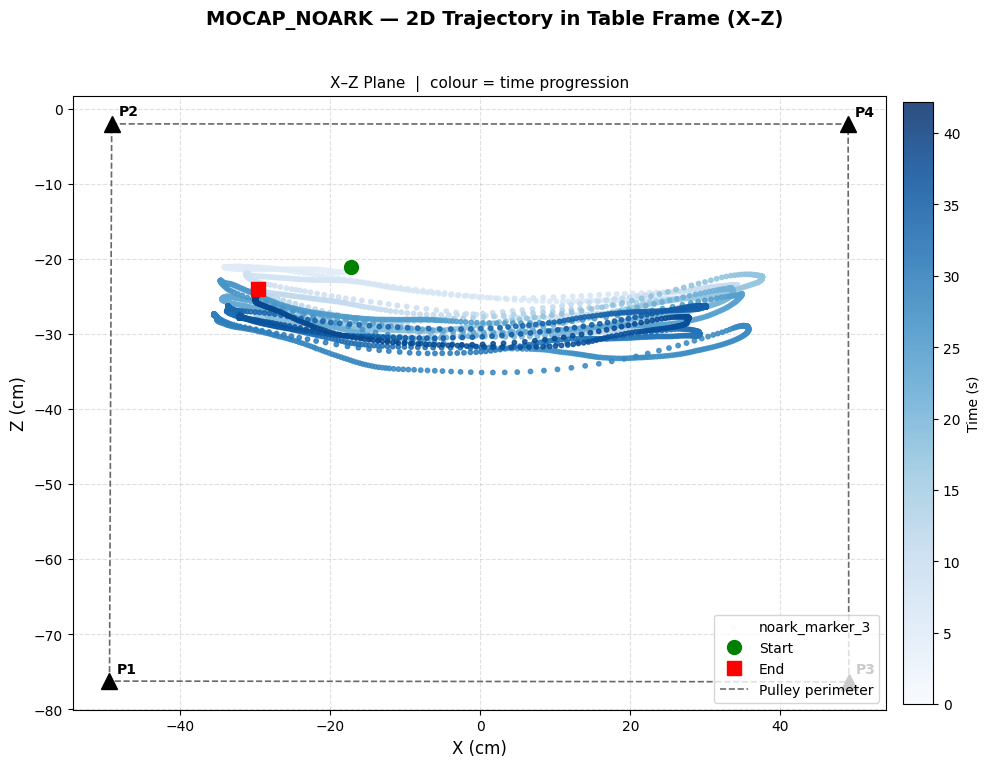

X range : nan → nan cm
Z range : nan → nan cm
Frames  : 4221  |  Duration: 42.20 s


In [67]:
# Cell 16
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()
_nm  = tframe_dfs['_noark_marker']

x_cam_cm = df_n[f'noark_m{_nm}_tf_x_m'].values * 100.0
z_cam_cm = df_n[f'noark_m{_nm}_tf_z_m'].values * 100.0
t_sec    = df_n['seconds'].values

# ── Pulley reference points (mean positions) ──────────────────────────────────
# Update PULLEY_MAP per recording using your notes sheet:
#   table_marker_3 = P1, table_marker_6 = P2, table_marker_2 = P3, table_marker_4 = P4
PULLEY_MAP = {'P1': 3, 'P2': 6, 'P3': 2, 'P4': 5}
pulley_pos = {}
for label, mid in PULLEY_MAP.items():
    xc = f'table_m{mid}_tf_x_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns and zc in df_t.columns:
        pulley_pos[label] = (
            df_t[xc].mean() * 100.0,
            df_t[zc].mean() * 100.0,
        )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f'MOCAP_NOARK — 2D Trajectory in Table Frame (X–Z)',
             fontsize=14, fontweight='bold')

sc = ax.scatter(
    x_cam_cm, z_cam_cm,
    c=t_sec, cmap='Blues',
    s=10, alpha=0.85,
    label=f'noark_marker_{_nm}',
    zorder=3,
)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label('Time (s)', fontsize=10)

ax.plot(x_cam_cm[0],  z_cam_cm[0],  'go', ms=10, zorder=5, label='Start')
ax.plot(x_cam_cm[-1], z_cam_cm[-1], 'rs', ms=10, zorder=5, label='End')

for lbl, (px, pz) in pulley_pos.items():
    ax.plot(px, pz, 'k^', ms=11, zorder=4)
    ax.annotate(lbl, (px, pz),
                xytext=(5, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

porder = ['P1', 'P2', 'P4', 'P3']
pcoords = [pulley_pos[p] for p in porder if p in pulley_pos]
if len(pcoords) == 4:
    pcoords_closed = pcoords + [pcoords[0]]
    ax.plot([p[0] for p in pcoords_closed],
            [p[1] for p in pcoords_closed],
            color='dimgray', lw=1.2, ls='--', zorder=2, label='Pulley perimeter')

ax.set_xlabel('X (cm)', fontsize=12)
ax.set_ylabel('Z (cm)', fontsize=12)
ax.set_title('X–Z Plane  |  colour = time progression', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(f'noark_m{_nm}_xz_trajectory_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range : {x_cam_cm.min():.2f} → {x_cam_cm.max():.2f} cm')
print(f'Z range : {z_cam_cm.min():.2f} → {z_cam_cm.max():.2f} cm')
print(f'Frames  : {len(t_sec)}  |  Duration: {t_sec[-1]-t_sec[0]:.2f} s')


## LOAD CAMERA DATA AND ENCODER DATA

In [68]:
# Cell 17
# 2. Update File paths using the / operator (cross-platform)
CAM_CSV = repo_root/"cam_enc_recordings"/"linear_fast_t1_may_4" / "camera_data.csv"
ENC_CSV = repo_root / "cam_enc_recordings" / "linear_fast_t1_may_4" / "encoder_data.csv"
print(f"Repo Root: {repo_root}")
# 3. Update Calibration paths to be relative to repo_root
CAM_CALIB_PATH   = repo_root / "notebooks" / "calibration" / "output" / "good.toml"
TABLE_CALIB_PATH = repo_root / "estimator" / "charuco_pose" / "charuco_pose.toml"

# ── Kinematics constants (from nkin.py) ──────────────────────────────────────
P2 = np.array([-0.495, 0, -0.027])   # Left upper pulley
P4 = np.array([ 0.495, 0, -0.027])   # Right upper pulley

r_ML = r_MR = 0.033   # Motor spool radius (m)

# ── Marker config (from camera_pose.py) ──────────────────────────────────────
MARKER_LENGTH = 0.049  # metres
MARKER_IDS    = [12, 14, 20]
MARKER_OFFSETS = {
    12: np.array([0,      0,  -0.055]),
    14: np.array([-0.126, 0,  -0.054]),
    20: np.array([ 0.126, 0,  -0.054]),
}

print("Config loaded ✓")

Repo Root: E:\Ragav\MS Bio Engineering\NOARK_backbone
Config loaded ✓


## LOAD CSV'S

In [69]:
# Cell 18
# ── Camera CSV ────────────────────────────────────────────────────────────────
cam_df = pd.read_csv(CAM_CSV, parse_dates=["timestamp"])
# print(f"Camera CSV: {len(cam_df)} rows")
cam_df.head(3)

,timestamp,sync_pin,tvec_12_x,tvec_12_y,tvec_12_z,tvec_14_x,tvec_14_y,tvec_14_z,tvec_20_x,tvec_20_y,tvec_20_z,rvec_12_x,rvec_12_y,rvec_12_z,rvec_14_x,rvec_14_y,rvec_14_z,rvec_20_x,rvec_20_y,rvec_20_z
0,2026-05-04 12:35:48.988481,0,0.153847,-0.043495,0.389695,NaN,NaN,NaN,NaN,NaN,NaN,-3.113070,0.005584,-0.036614,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-04 12:35:49.017955,0,0.153930,-0.043516,0.389881,NaN,NaN,NaN,NaN,NaN,NaN,-3.109790,0.006290,-0.036223,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-04 12:35:49.041101,0,0.153861,-0.043510,0.389783,NaN,NaN,NaN,NaN,NaN,NaN,-3.113005,0.006003,-0.034325,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# Cell 19
# ── Encoder CSV ───────────────────────────────────────────────────────────────
enc_df = pd.read_csv(ENC_CSV, parse_dates=["timestamp"])
# print(f"Encoder CSV: {len(enc_df)} rows")
enc_df.head(3)

,timestamp,Millis,enc1,enc2
0,2026-05-04 12:35:48.961827,4673.05,0.0,0.0
1,2026-05-04 12:35:48.963830,4675.05,0.0,0.0
2,2026-05-04 12:35:48.965805,4677.03,0.0,0.0


In [71]:
# Cell 20
# ── Find sync pin rising edge — first row where sync_pin transitions to 1 ────
assert 'sync_pin' in cam_df.columns, f"sync_pin column not found. Columns: {cam_df.columns.tolist()}"

sync_rows = cam_df[cam_df['sync_pin'] == 1]
assert len(sync_rows) > 0, "sync_pin never goes HIGH — check your hardware/CSV"

# Rising edge = first row where sync_pin == 1
sync_idx       = sync_rows.index[0]
sync_timestamp = pd.Timestamp(cam_df.loc[sync_idx, 'timestamp'])

print(f"Sync pin rising edge at row : {sync_idx}")
print(f"Sync timestamp (wall-clock) : {sync_timestamp}")
print(f"Rows before sync (discarded): {sync_idx}")
print(f"Rows from sync onward       : {len(cam_df) - sync_idx}")

# Optional: inspect a few rows around the rising edge
print("\nRows around sync edge:")
print(cam_df[['timestamp', 'sync_pin']].iloc[max(0, sync_idx-2) : sync_idx+4].to_string())

Sync pin rising edge at row : 224
Sync timestamp (wall-clock) : 2026-05-04 12:35:52.571443
Rows before sync (discarded): 224
Rows from sync onward       : 2891

Rows around sync edge:
                     timestamp  sync_pin
222 2026-05-04 12:35:52.540338         0
223 2026-05-04 12:35:52.557437         0
224 2026-05-04 12:35:52.571443         1
225 2026-05-04 12:35:52.586607         1
226 2026-05-04 12:35:52.600946         1
227 2026-05-04 12:35:52.615698         1


Sync column      : 'sync_pin'
Unique values    : [0 1]
Trigger edges    : 1
First trigger at : 3.583 s
Last  trigger at : 3.583 s


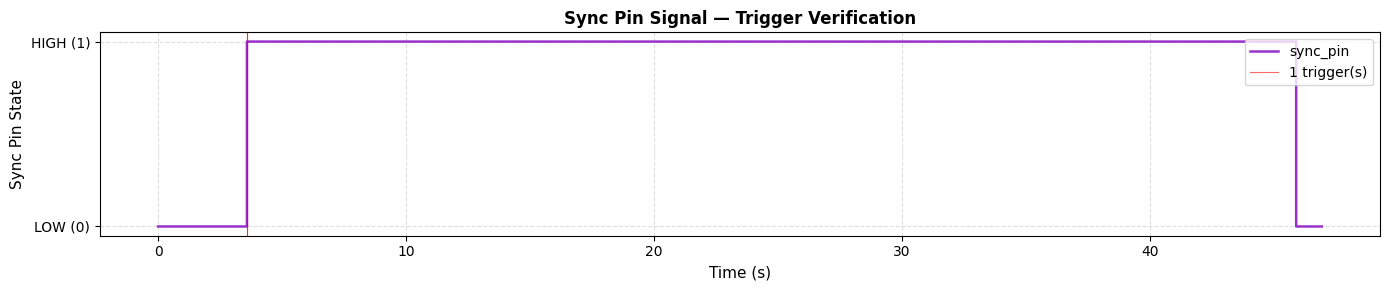

In [72]:
# Cell 21
# ── Sync Pin Verification ─────────────────────────────────────────────────────
# Plots the sync pin channel from encoder CSV to confirm trigger was received.
# Expects a column named 'sync' (or 'sync_pin') in cam_df.

SYNC_COL = next((c for c in cam_df.columns if 'sync' in c.lower()), None)

if SYNC_COL is None:
    print(f" No sync column found. Available columns: {cam_df.columns.tolist()}")
else:
    # Convert to numeric, coerce any non-numeric to NaN
    sync_signal = pd.to_numeric(cam_df[SYNC_COL], errors='coerce').values
    sync_time   = (cam_df['timestamp'] - cam_df['timestamp'].iloc[0]).dt.total_seconds().values

    # Detect edges (LOW→HIGH transitions = trigger events)
    trigger_indices = np.where(np.diff(sync_signal.astype(float)) > 0)[0] + 1
    print(f"Sync column      : '{SYNC_COL}'")
    print(f"Unique values    : {np.unique(sync_signal[~np.isnan(sync_signal)])}")
    print(f"Trigger edges    : {len(trigger_indices)}")
    if len(trigger_indices):
        print(f"First trigger at : {sync_time[trigger_indices[0]]:.3f} s")
        print(f"Last  trigger at : {sync_time[trigger_indices[-1]]:.3f} s")

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.step(sync_time, sync_signal, where='post', color='darkorchid', lw=1.8, label=SYNC_COL)

    # Mark each trigger edge
    for idx in trigger_indices:
        ax.axvline(sync_time[idx], color='red', lw=0.8, alpha=0.6)
    if len(trigger_indices):
        ax.axvline(sync_time[trigger_indices[0]], color='red', lw=0.8, alpha=0.6,
                   label=f'{len(trigger_indices)} trigger(s)')

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Sync Pin State', fontsize=11)
    ax.set_title('Sync Pin Signal — Trigger Verification', fontsize=12, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['LOW (0)', 'HIGH (1)'])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('sync_pin_verification.png', dpi=150, bbox_inches='tight')
    plt.show()

## LOAD CAMERA CALIBRATION AND BUILD HELPERS

In [73]:
# Cell 22
# ── Load table reference frame only ──────────────────────────────────────────
tbl     = toml.load(TABLE_CALIB_PATH)
R_table = np.array(tbl["rotation_matrix"]).reshape(3, 3)
T_table = np.array(tbl["tvec"]).reshape(3, 1)

# Sanity checks
assert R_table.shape == (3, 3), f"R_table wrong shape: {R_table.shape}"
assert T_table.shape == (3, 1), f"T_table wrong shape: {T_table.shape}"

print("Table rotation R:")
print(np.round(R_table, 4))
print("\nTable translation T (m):", T_table.flatten().round(4))
print("\nShapes OK ✓")

Table rotation R:
[[-0.9964  0.0015 -0.0846]
 [-0.0067 -0.9981  0.0615]
 [-0.0843  0.0618  0.9945]]

Table translation T (m): [-0.023   0.0203  0.6899]

Shapes OK ✓


## Reconstruct NOARK Position from Camera Data

For each frame we:
1. Take the raw `tvec` / `rvec` for each detected marker (already stored by `Cam_Data_log.py`)
2. Apply the marker-specific physical offset to get the handle position in camera frame
3. Average all available marker positions → **centroid in camera frame**
4. Transform to **table frame**: `P_table = R_table.T @ (P_cam - T_table)`

In [74]:
# Cell 23
# ── Data sanity check ─────────────────────────────────────────────────────────
print("Shape:", cam_df.shape)

print("\n--- NaN counts per marker ---")
for mid in [12, 14, 20]:
    col = f'tvec_{mid}_x'
    print(f"Marker {mid} NaN rows: {cam_df[col].isna().sum()} / {len(cam_df)}")

print("\n--- Rows where ALL 3 markers missing ---")
all_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().all(axis=1)
print(f"Count: {all_missing.sum()}")

print("\n--- Rows where ANY marker missing ---")
any_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().any(axis=1)
print(f"Count: {any_missing.sum()}")

print("\n--- Sample of raw tvec values (first 10 rows) ---")
print(cam_df[['timestamp','tvec_12_x','tvec_14_x','tvec_20_x']].head(10).to_string())

Shape: (3115, 20)

--- NaN counts per marker ---
Marker 12 NaN rows: 349 / 3115
Marker 14 NaN rows: 2401 / 3115
Marker 20 NaN rows: 2045 / 3115

--- Rows where ALL 3 markers missing ---
Count: 2

--- Rows where ANY marker missing ---
Count: 3115

--- Sample of raw tvec values (first 10 rows) ---
                   timestamp  tvec_12_x  tvec_14_x  tvec_20_x
0 2026-05-04 12:35:48.988481   0.153847        NaN        NaN
1 2026-05-04 12:35:49.017955   0.153930        NaN        NaN
2 2026-05-04 12:35:49.041101   0.153861        NaN        NaN
3 2026-05-04 12:35:49.067030   0.153805        NaN        NaN
4 2026-05-04 12:35:49.098462   0.153756        NaN        NaN
5 2026-05-04 12:35:49.117252   0.153695        NaN        NaN
6 2026-05-04 12:35:49.134210   0.153691        NaN        NaN
7 2026-05-04 12:35:49.151436   0.153757        NaN        NaN
8 2026-05-04 12:35:49.166115   0.153733        NaN        NaN
9 2026-05-04 12:35:49.180039   0.153761        NaN        NaN


In [75]:
# Cell 24
def get_centroid_cam(row, marker_ids=MARKER_IDS, offsets=MARKER_OFFSETS):
    """
    Replicates camera_pose.py::_get_centroid().
    Returns centroid in CAMERA frame as (3,1), or None if no marker visible.
    """
    points = []
    for mid in marker_ids:
        tvec_cols = [f"tvec_{mid}_x", f"tvec_{mid}_y", f"tvec_{mid}_z"]
        rvec_cols = [f"rvec_{mid}_x", f"rvec_{mid}_y", f"rvec_{mid}_z"]
        tvec = row[tvec_cols].values.astype(float)
        rvec = row[rvec_cols].values.astype(float)
        if np.any(np.isnan(tvec)) or np.any(np.isnan(rvec)):
            continue
        R_marker, _ = cv2.Rodrigues(rvec)
        offset = offsets[mid].reshape(3, 1)
        pos_cam = R_marker @ offset + tvec.reshape(3, 1)
        points.append(pos_cam.flatten())
    if not points:
        return None
    return np.mean(points, axis=0).reshape(3, 1)


def cam_to_table(p_cam, R_table=R_table, T_table=T_table):
    """
    Replicates camera_pose.py::_get_local_coordinates().
    P_table = R_table.T @ (P_cam - T_table)
    """
    return (R_table.T @ (p_cam - T_table)).flatten()


# Apply row-wise
results = []
for _, row in cam_df.iterrows():
    p_cam = get_centroid_cam(row)
    if p_cam is None:
        results.append([np.nan, np.nan, np.nan])
    else:
        results.append(cam_to_table(p_cam))

pos_cam = pd.DataFrame(results, columns=["x_cam", "y_cam", "z_cam"])
cam_df  = pd.concat([cam_df.reset_index(drop=True), pos_cam], axis=1)

## Reconstruct NOARK Position from Encoder Data

Replicates the kinematics in `nkin.py`:
1. At the **zero event** (first encoder row), capture camera-derived free lengths `P2_to_NOARK_init` and `P4_to_NOARK_init`
2. For each encoder tick: `L_free_L = init_L + r_ML * deg2rad(enc1)`, `L_free_R = init_R - r_MR * deg2rad(enc2)`
3. Solve **circle–circle intersection** between `P2` (radius `L_free_L`) and `P4` (radius `L_free_R`) to get `(x, z)` in table frame

In [76]:
# # Cell 25
# #  Find the zero-reference using camera position ─────────────────────────
# init_row = cam_df.iloc[0]  # first camera frame — no dropna needed
# N0 = np.array([init_row["x_cam"], 0, init_row["z_cam"]])
# print(N0)
# P2_to_NOARK_init = sqrt((N0[0] - P2[0])**2 + (N0[2] - P2[2])**2)  # P2 is left pulley, camera data
# P4_to_NOARK_init = sqrt((N0[0] - P4[0])**2 + (N0[2] - P4[2])**2)  # P4 is right pulley, camera data
# # take Noark marker m2 and p2 marker and then subtract it to get the P2_to_NOARK_init do the same for P4_to_NOARK_init do this step
# print(f"Init position (table frame)_camera_data:  x={N0[0]*100:.2f} cm   z={N0[2]*100:.2f} cm")
# print(f"P2_to_NOARK_init: {P2_to_NOARK_init*100:.2f} cm")
# print(f"P4_to_NOARK_init: {P4_to_NOARK_init*100:.2f} cm")

In [77]:
# Cell — MoCap Init Position + Distance to P2 and P4
from math import sqrt

_nm  = tframe_dfs['_noark_marker']
df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()

# ── Initial NOARK position (first frame) ─────────────────────────────────────
xcol = f'noark_m{_nm}_tf_x_m'
zcol = f'noark_m{_nm}_tf_z_m'

N0_mocap = np.array([df_n.loc[0, xcol], 0, df_n.loc[0, zcol]])
print(f"Init position (tframe)_mocap_data:  x={N0_mocap[0]*100:.2f} cm   z={N0_mocap[2]*100:.2f} cm")

# ── P2 and P4 pulley positions from table markers (tframe, first frame) ───────
# From notes: table_marker_6 = P2 (left pulley), table_marker_5 = P4 (right pulley)
# P2_mocap = np.array([df_t.loc[0, 'table_m6_tf_x_m'], 0, df_t.loc[0, 'table_m6_tf_z_m']])
# P4_mocap = np.array([df_t.loc[0, 'table_m5_tf_x_m'], 0, df_t.loc[0, 'table_m5_tf_z_m']])
P2_mocap = np.array([df_t['table_m6_tf_x_m'].mean(), 0, df_t['table_m6_tf_z_m'].mean()])
P4_mocap = np.array([df_t['table_m5_tf_x_m'].mean(), 0, df_t['table_m5_tf_z_m'].mean()])
print(f"P2 position (tframe)_mocap_data:  x={P2_mocap[0]*100:.2f} cm   z={P2_mocap[2]*100:.2f} cm")
print(f"P4 position (tframe)_mocap_data:  x={P4_mocap[0]*100:.2f} cm   z={P4_mocap[2]*100:.2f} cm")
# ── Distances (same formula as Cell 25) ──────────────────────────────────────
P2_to_NOARK_init_mocap = sqrt((N0_mocap[0] - P2_mocap[0])**2 + (N0_mocap[2] - P2_mocap[2])**2)
P4_to_NOARK_init_mocap = sqrt((N0_mocap[0] - P4_mocap[0])**2 + (N0_mocap[2] - P4_mocap[2])**2)

print(f"P2_to_NOARK_init_mocap: {P2_to_NOARK_init_mocap*100:.2f} cm")
print(f"P4_to_NOARK_init_mocap: {P4_to_NOARK_init_mocap*100:.2f} cm")

Init position (tframe)_mocap_data:  x=-17.22 cm   z=-21.10 cm
P2 position (tframe)_mocap_data:  x=-49.13 cm   z=-1.99 cm
P4 position (tframe)_mocap_data:  x=49.02 cm   z=-2.01 cm
P2_to_NOARK_init_mocap: 37.20 cm
P4_to_NOARK_init_mocap: 68.94 cm


In [78]:
# Cell 26
#  Circle-circle intersection (ENCODER) ────────────────────────────────

def circle_intersect_xz(p2, p4, r_l, r_r):
    """
    Finds the intersection of two circles in the X-Z plane.
    p2, p4 : 3-element arrays, only [0] (X) and [2] (Z) are used
    r_l    : radius of circle centred at p2  (left cable free length)
    r_r    : radius of circle centred at p4  (right cable free length)
    Returns (x, z) of the 'upper' solution (enc_1 in nkin.py), or (nan, nan).
    """
    # x2, z2 = p2[0], p2[2] #camera-based pulley positions from table markers (tframe, first frame)
    # x4, z4 = p4[0], p4[2] #camera-based pulley positions from table markers (tframe, first frame)
    x2, z2 = p2[0], p2[2] #mocap-based pulley positions from table markers (tframe, first frame)
    x4, z4 = p4[0], p4[2] #mocap-based pulley positions from table markers (tframe, first frame)
    d = sqrt((x4 - x2)**2 + (z4 - z2)**2)

    # Triangle feasibility check
    if d > r_l + r_r or d < abs(r_l - r_r) or d == 0:
        return np.nan, np.nan

    a  = (r_l**2 - r_r**2 + d**2) / (2 * d)
    h2 = r_l**2 - a**2
    if h2 < 0:
        return np.nan, np.nan
    h = sqrt(h2)

    xm = x2 + a * (x4 - x2) / d
    zm = z2 + a * (z4 - z2) / d

    # 'enc_1' solution — matches nkin.py x_enc_1 / z_enc_1
    x_sol = xm + h * (z4 - z2) / d
    z_sol = zm - h * (x4 - x2) / d
    return x_sol, z_sol


# ── Step 4c: Compute encoder-based positions ──────────────────────────────────
x_enc_list, z_enc_list = [], []

for _, row in enc_df.iterrows():
    delta_L = r_ML * np.deg2rad(float(row["enc1"]))
    delta_R = r_MR * np.deg2rad(float(row["enc2"]))

    # L_free_L = P2_to_NOARK_init + delta_L  # using camera-based init distances as reference
    # L_free_R = P4_to_NOARK_init - delta_R  # using camera-based init distances as reference  
    
    
    L_free_L = P2_to_NOARK_init_mocap + delta_L  # using mocap -based init distances as reference
    L_free_R = P4_to_NOARK_init_mocap - delta_R  # using mocap -based init distances as reference
  
    x_e, z_e = circle_intersect_xz(P2_mocap, P4_mocap, L_free_L, L_free_R)
    x_enc_list.append(x_e)
    z_enc_list.append(z_e)

enc_df["x_enc"] = x_enc_list
enc_df["z_enc"] = z_enc_list

print(f"Valid encoder frames: {enc_df['x_enc'].notna().sum()} / {len(enc_df)}")
enc_df[["timestamp", "enc1", "enc2", "x_enc", "z_enc"]].head(5).round(4)

Valid encoder frames: 23403 / 23403


,timestamp,enc1,enc2,x_enc,z_enc
0,2026-05-04 12:35:48.961827,0.0,0.0,-0.1722,-0.211
1,2026-05-04 12:35:48.963830,0.0,0.0,-0.1722,-0.211
2,2026-05-04 12:35:48.965805,0.0,0.0,-0.1722,-0.211
3,2026-05-04 12:35:48.967727,0.0,0.0,-0.1722,-0.211
4,2026-05-04 12:35:48.969718,0.0,0.0,-0.1722,-0.211


## Time-Align Camera and Encoder Signals

Both CSVs use wall-clock timestamps. We align them by interpolating encoder onto the camera time grid.

In [79]:
# Cell 27
# ── Use sync pin timestamp as the single common t0 for all signals ────────────
cam_df['timestamp'] = pd.to_datetime(cam_df['timestamp'])
enc_df['timestamp'] = pd.to_datetime(enc_df['timestamp'])

# t0 is now the hardware sync moment — not an arbitrary CSV start
t0 = sync_timestamp

cam_df['t_sec'] = (cam_df['timestamp'] - t0).dt.total_seconds()
enc_df['t_sec'] = (enc_df['timestamp'] - t0).dt.total_seconds()

# Keep only rows from sync onward (t_sec >= 0) for camera
# Encoder rows before sync are kept — they define the init cable lengths
cam_sync = cam_df[cam_df['t_sec'] >= 0].sort_values('t_sec').reset_index(drop=True)
enc_s    = enc_df.sort_values('t_sec').reset_index(drop=True)

print(f"Camera frames before sync (dropped) : {(cam_df['t_sec'] < 0).sum()}")
print(f"Camera frames from sync onward      : {len(cam_sync)}")
print(f"Encoder frames total                : {len(enc_s)}")
print(f"t_sec=0 is now the sync pin moment  : {sync_timestamp}")

interp_x = interp1d(enc_s['t_sec'], enc_s['x_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)
interp_z = interp1d(enc_s['t_sec'], enc_s['z_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)

merged = cam_sync.copy()
merged['x_enc'] = interp_x(merged['t_sec'])
merged['z_enc'] = interp_z(merged['t_sec'])

for col in ['x_cam', 'z_cam', 'x_enc', 'z_enc']:
    merged[col + '_cm'] = merged[col] * 100

print(f"\nTotal merged frames  : {len(merged)}")
print(f"Valid cam frames     : {merged['x_cam'].notna().sum()}")
merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm']].head(5).round(3)


Camera frames before sync (dropped) : 224
Camera frames from sync onward      : 2891
Encoder frames total                : 23403
t_sec=0 is now the sync pin moment  : 2026-05-04 12:35:52.571443

Total merged frames  : 2891
Valid cam frames     : 2889


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm
0,0.000,-15.422,-26.205,-17.219,-21.103
1,0.015,-15.434,-26.188,-17.219,-21.103
2,0.030,-15.430,-26.189,-17.219,-21.103
3,0.044,-15.409,-26.219,-17.219,-21.103
4,0.059,-15.404,-26.224,-17.219,-21.103


# ── Mocap time alignment using sync pin ───────────────────────────────────────
# noark_st_time = wall-clock time when Motive started saving (triggered by sync pin)
# sync_timestamp = wall-clock time of the sync pin rising edge in camera CSV
# These should be nearly identical — offset_sec should be close to 0

In [80]:
# Cell 28
# ── Extract mocap position arrays in cm ───────────────────────────────────────
df_mocap = tframe_dfs['noark_in_tframe'].copy()
_nm = tframe_dfs['_noark_marker'] 

_mask   = df_mocap[f'noark_m{_nm}_tf_x_m'].notna() & df_mocap[f'noark_m{_nm}_tf_z_m'].notna()
mocap_t = df_mocap.loc[_mask, 'seconds'].values
mocap_x = df_mocap.loc[_mask, f'noark_m{_nm}_tf_x_m'].values * 100.0
mocap_z = df_mocap.loc[_mask, f'noark_m{_nm}_tf_z_m'].values * 100.0


print(f"Mocap frames : {len(mocap_t)}  (from {len(df_mocap)} total, {len(df_mocap)-len(mocap_t)} NaN rows dropped)")
print(f"Mocap X range: {mocap_x.min():.2f} → {mocap_x.max():.2f} cm")
print(f"Mocap Z range: {mocap_z.min():.2f} → {mocap_z.max():.2f} cm")

# ── Interpolate onto merged time grid ─────────────────────────────────────────
interp_mocap_x = interp1d(mocap_t, mocap_x, kind='linear', bounds_error=False, fill_value=np.nan)
interp_mocap_z = interp1d(mocap_t, mocap_z, kind='linear', bounds_error=False, fill_value=np.nan)

merged['x_mocap_cm'] = interp_mocap_x(merged['t_sec'])
merged['z_mocap_cm'] = interp_mocap_z(merged['t_sec'])

valid_mocap = merged['x_mocap_cm'].notna().sum()
print(f"\nValid mocap frames: {valid_mocap} / {len(merged)}")

overlap = min(mocap_t[-1], merged['t_sec'].iloc[-1]) - max(mocap_t[0], merged['t_sec'].iloc[0])
print(f"Overlap : {overlap:.3f} s  {'✓ OK' if overlap > 1.0 else '✗ BAD — check time origins!'}")

merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm',
        'x_mocap_cm', 'z_mocap_cm']].head(5).round(3)

Mocap frames : 4220  (from 4221 total, 1 NaN rows dropped)
Mocap X range: -35.50 → 37.58 cm
Mocap Z range: -35.13 → -21.00 cm

Valid mocap frames: 2813 / 2891
Overlap : 42.200 s  ✓ OK


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm,x_mocap_cm,z_mocap_cm
0,0.000,-15.422,-26.205,-17.219,-21.103,-17.219,-21.103
1,0.015,-15.434,-26.188,-17.219,-21.103,-17.219,-21.104
2,0.030,-15.430,-26.189,-17.219,-21.103,-17.216,-21.103
3,0.044,-15.409,-26.219,-17.219,-21.103,-17.218,-21.106
4,0.059,-15.404,-26.224,-17.219,-21.103,-17.218,-21.103


In [81]:
# # Cell 28b — Bias correction (anchor encoder and camera to mocap at first valid frame)

# # ── Find first valid index for each sensor vs mocap ───────────────────────────
# first_valid_enc = merged[
#     merged['x_enc_cm'].notna() & merged['x_mocap_cm'].notna()
# ].index[0]

# first_valid_cam = merged[
#     merged['x_cam_cm'].notna() & merged['x_mocap_cm'].notna()
# ].index[0]

# # ── Encoder bias ──────────────────────────────────────────────────────────────
# # bias_enc_x = merged.loc[first_valid_enc, 'x_enc_cm'] - merged.loc[first_valid_enc, 'x_mocap_cm']
# # bias_enc_z = merged.loc[first_valid_enc, 'z_enc_cm'] - merged.loc[first_valid_enc, 'z_mocap_cm']

# print(f"Encoder at first valid: X={merged.loc[first_valid_enc, 'x_enc_cm']:.3f}  Z={merged.loc[first_valid_enc, 'z_enc_cm']:.3f}")
# print(f"Mocap   at first valid: X={merged.loc[first_valid_enc, 'x_mocap_cm']:.3f}  Z={merged.loc[first_valid_enc, 'z_mocap_cm']:.3f}")
# # print(f"Encoder bias:           X={bias_enc_x:.3f}  Z={bias_enc_z:.3f} cm\n")

# # merged['x_enc_cm'] = merged['x_enc_cm'] - bias_enc_x + bias_enc_x
# # merged['z_enc_cm'] = merged['z_enc_cm'] - bias_enc_z + bias_enc_z
# # ── Camera bias ───────────────────────────────────────────────────────────────
# # bias_cam_x = merged.loc[first_valid_cam, 'x_cam_cm'] - merged.loc[first_valid_cam, 'x_mocap_cm']
# # bias_cam_z = merged.loc[first_valid_cam, 'z_cam_cm'] - merged.loc[first_valid_cam, 'z_mocap_cm']

# print(f"Camera  at first valid: X={merged.loc[first_valid_cam, 'x_cam_cm']:.3f}  Z={merged.loc[first_valid_cam, 'z_cam_cm']:.3f}")
# print(f"Mocap   at first valid: X={merged.loc[first_valid_cam, 'x_mocap_cm']:.3f}  Z={merged.loc[first_valid_cam, 'z_mocap_cm']:.3f}")
# # print(f"Camera  bias:           X={bias_cam_x:.3f}  Z={bias_cam_z:.3f} cm")

# # merged['x_cam_cm'] = merged['x_cam_cm'] - bias_cam_x + bias_cam_x
# # merged['z_cam_cm'] = merged['z_cam_cm'] - bias_cam_z + bias_cam_z

In [82]:
# Cell 28b — First-frame alignment check (inspection only, no correction)

first_valid_enc = merged[
    merged['x_enc_cm'].notna() & merged['x_mocap_cm'].notna()
].index[0]

first_valid_cam = merged[
    merged['x_cam_cm'].notna() & merged['x_mocap_cm'].notna()
].index[0]

print(f"Encoder at first valid: X={merged.loc[first_valid_enc, 'x_enc_cm']:.3f}  Z={merged.loc[first_valid_enc, 'z_enc_cm']:.3f}")
print(f"Mocap   at first valid: X={merged.loc[first_valid_enc, 'x_mocap_cm']:.3f}  Z={merged.loc[first_valid_enc, 'z_mocap_cm']:.3f}")
print()
print(f"Camera  at first valid: X={merged.loc[first_valid_cam, 'x_cam_cm']:.3f}  Z={merged.loc[first_valid_cam, 'z_cam_cm']:.3f}")
print(f"Mocap   at first valid: X={merged.loc[first_valid_cam, 'x_mocap_cm']:.3f}  Z={merged.loc[first_valid_cam, 'z_mocap_cm']:.3f}")

Encoder at first valid: X=-17.219  Z=-21.103
Mocap   at first valid: X=-17.219  Z=-21.103

Camera  at first valid: X=-15.422  Z=-26.205
Mocap   at first valid: X=-17.219  Z=-21.103


In [83]:
# ── Time alignment diagnostic (run after Cell 28) ────────────────────────────

# 1. Sync pin and MoCap start times
print(f"Sync pin wall-clock time     : {sync_timestamp}")
print(f"MoCap recording start (wall) : {noark_st_time}")
mocap_time_offset = (noark_st_time - sync_timestamp).total_seconds()
print(f"MoCap started {mocap_time_offset:.3f} s AFTER sync pin")
print()

# 2. Time ranges
print(f"merged t_sec range           : {merged['t_sec'].min():.3f} → {merged['t_sec'].max():.3f} s")
print(f"mocap_t range (raw seconds)  : {mocap_t.min():.3f} → {mocap_t.max():.3f} s")
print()

# 3. Overlap check — raw vs aligned
raw_overlap = (min(mocap_t[-1], merged['t_sec'].iloc[-1])
             - max(mocap_t[0],  merged['t_sec'].iloc[0]))
aligned_mocap_t = mocap_t + mocap_time_offset
aligned_overlap = (min(aligned_mocap_t[-1], merged['t_sec'].iloc[-1])
                 - max(aligned_mocap_t[0],  merged['t_sec'].iloc[0]))

print(f"Overlap using RAW mocap_t    : {raw_overlap:.3f} s  {'✓' if raw_overlap > 1 else '✗ BAD'}")
print(f"Overlap using ALIGNED mocap_t: {aligned_overlap:.3f} s  {'✓' if aligned_overlap > 1 else '✗ BAD'}")
print()

# 4. Spot check first 5 rows
print("First 5 merged rows:")
print(merged[['t_sec', 'x_mocap_cm', 'z_mocap_cm',
              'x_enc_cm', 'z_enc_cm']].head(5).round(3).to_string())

Sync pin wall-clock time     : 2026-05-04 12:35:52.571443
MoCap recording start (wall) : 2026-05-04 12:35:52.446000
MoCap started -0.125 s AFTER sync pin

merged t_sec range           : 0.000 → 43.342 s
mocap_t range (raw seconds)  : 0.000 → 42.200 s

Overlap using RAW mocap_t    : 42.200 s  ✓
Overlap using ALIGNED mocap_t: 42.075 s  ✓

First 5 merged rows:
   t_sec  x_mocap_cm  z_mocap_cm  x_enc_cm  z_enc_cm
0  0.000     -17.219     -21.103   -17.219   -21.103
1  0.015     -17.219     -21.104   -17.219   -21.103
2  0.030     -17.216     -21.103   -17.219   -21.103
3  0.044     -17.218     -21.106   -17.219   -21.103
4  0.059     -17.218     -21.103   -17.219   -21.103


In [84]:
# # ── Null out mocap dropout window (t=28–34s) ──────────────────────────────────
# # Mocap marker was occluded here — interp1d gives wrong slow ramp
# # These frames must be excluded from error stats
# DROPOUT_START = 28.0
# DROPOUT_END   = 34.0
# dropout_window = (merged['t_sec'] >= DROPOUT_START) & (merged['t_sec'] <= DROPOUT_END)
# merged.loc[dropout_window, 'x_mocap_cm'] = np.nan
# merged.loc[dropout_window, 'z_mocap_cm'] = np.nan
# print(f"Nulled out {dropout_window.sum()} mocap frames in dropout window ({DROPOUT_START}–{DROPOUT_END}s)")

## ALIGNMENT SANITY CHECK

If mocap and camera traces are horizontally offset (time-shifted), `offset_sec` is wrong and all error stats will be meaningless. Fix by adjusting the offset manually until traces overlap.

In [85]:
# # Cell 30a — Sanity check on RAW signals (before bias correction)
# # Re-interpolate raw mocap without any correction for honest comparison
# interp_raw_x = interp1d(mocap_t, mocap_x, kind='linear', bounds_error=False, fill_value=np.nan)
# interp_raw_z = interp1d(mocap_t, mocap_z, kind='linear', bounds_error=False, fill_value=np.nan)

# fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
# fig.suptitle('Alignment Sanity Check — RAW Mocap vs Camera (no offset correction)', fontsize=13, fontweight='bold')

# axes[0].plot(merged['t_sec'], interp_raw_x(merged['t_sec']), color='black',     lw=1.8, label='Mocap X (raw)')
# axes[0].plot(merged['t_sec'], merged['x_cam_cm'] + bias_cam_x, color='steelblue', lw=1.2, ls='--', label='Camera X (raw)')
# axes[0].legend(fontsize=10); axes[0].set_title('X axis — raw offset visible here', fontsize=11)
# axes[0].grid(True, alpha=0.4); axes[0].set_ylabel('X (cm)', fontsize=10)

# axes[1].plot(merged['t_sec'], interp_raw_z(merged['t_sec']), color='black',    lw=1.8, label='Mocap Z (raw)')
# axes[1].plot(merged['t_sec'], merged['z_cam_cm'] + bias_cam_z, color='seagreen', lw=1.2, ls='--', label='Camera Z (raw)')
# axes[1].legend(fontsize=10); axes[1].set_title('Z axis — raw offset visible here', fontsize=11)
# axes[1].grid(True, alpha=0.4); axes[1].set_ylabel('Z (cm)', fontsize=10)
# axes[1].set_xlabel('Time (s)', fontsize=11)

# print(f"Raw camera bias — X: {bias_cam_x:.3f} cm   Z: {bias_cam_z:.3f} cm")
# print(f"If these are small (<1 cm), bias correction is valid.")
# print(f"If these are large (>5 cm), the two sensors are tracking different points.")

# plt.tight_layout()
# plt.show()

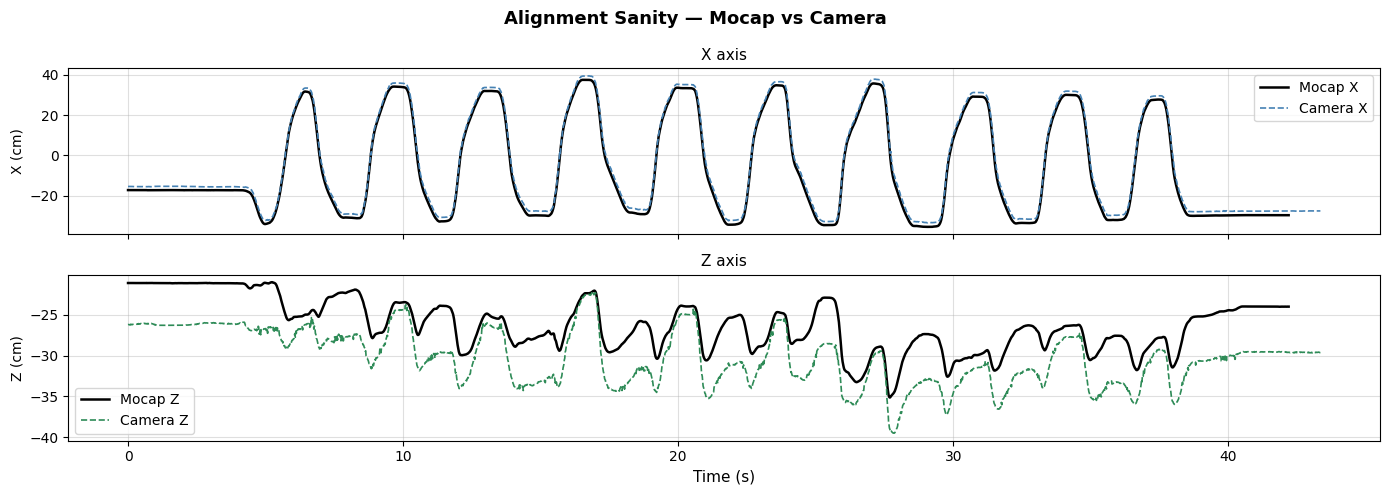

If the two traces are time-shifted, adjust offset_sec in the cell above until they overlap.


In [86]:
# Cell 30b
# ── Quick alignment sanity check — mocap should overlap with camera ───────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle('Alignment Sanity — Mocap vs Camera', fontsize=13, fontweight='bold')

axes[0].plot(merged['t_sec'], merged['x_mocap_cm'], color='black',    lw=1.8, label='Mocap X')
axes[0].plot(merged['t_sec'], merged['x_cam_cm'],   color='steelblue', lw=1.2, ls='--', label='Camera X')
axes[0].legend(fontsize=10); axes[0].set_title('X axis', fontsize=11)
axes[0].grid(True, alpha=0.4); axes[0].set_ylabel('X (cm)', fontsize=10)

axes[1].plot(merged['t_sec'], merged['z_mocap_cm'], color='black',   lw=1.8, label='Mocap Z')
axes[1].plot(merged['t_sec'], merged['z_cam_cm'],   color='seagreen', lw=1.2, ls='--', label='Camera Z')
axes[1].legend(fontsize=10); axes[1].set_title('Z axis', fontsize=11)
axes[1].grid(True, alpha=0.4); axes[1].set_ylabel('Z (cm)', fontsize=10)
axes[1].set_xlabel('Time (s)', fontsize=11)

plt.tight_layout()
plt.show()
print("If the two traces are time-shifted, adjust offset_sec in the cell above until they overlap.")

## ERROR STATISTICS — Camera vs Encoder

In [87]:
# ── Compute raw error columns ─────────────────────────────────────────────────
merged["err_x_cm"] = merged["x_enc_cm"] - merged["x_cam_cm"]
merged["err_z_cm"] = merged["z_enc_cm"] - merged["z_cam_cm"]

err_x = merged["err_x_cm"].to_numpy()
err_z = merged["err_z_cm"].to_numpy()

mask        = ~np.isnan(err_x) & ~np.isnan(err_z)
err_x_valid = err_x[mask]
err_z_valid = err_z[mask]

def arr_stats(arr, name):
    print(f"{name:15s}  mean={arr.mean():.3f}  std={arr.std():.3f}"
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"RMSE={np.sqrt((arr**2).mean()):.3f}  "
          f"95th={np.percentile(arr, 95):.3f}")

print(f"Valid frames : {mask.sum()} / {len(mask)}")
arr_stats(err_x_valid, "err_x_cm")
arr_stats(err_z_valid, "err_z_cm")
print()
print(f"Mean absolute error X : {np.mean(np.abs(err_x_valid)):.3f} cm")
print(f"Mean absolute error Z : {np.mean(np.abs(err_z_valid)):.3f} cm")
print(f"Max absolute error X  : {np.max(np.abs(err_x_valid)):.3f} cm")
print(f"Max absolute error Z  : {np.max(np.abs(err_z_valid)):.3f} cm")

Valid frames : 2888 / 2891
err_x_cm         mean=-1.706  std=2.143min=-7.501  max=16.006  RMSE=2.739  95th=1.641
err_z_cm         mean=2.008  std=3.707min=-21.306  max=5.729  RMSE=4.216  95th=5.172

Mean absolute error X : 2.280 cm
Mean absolute error Z : 3.377 cm
Max absolute error X  : 16.006 cm
Max absolute error Z  : 21.306 cm


## Plot 1: Time-Series Comparison — Camera vs Encoder

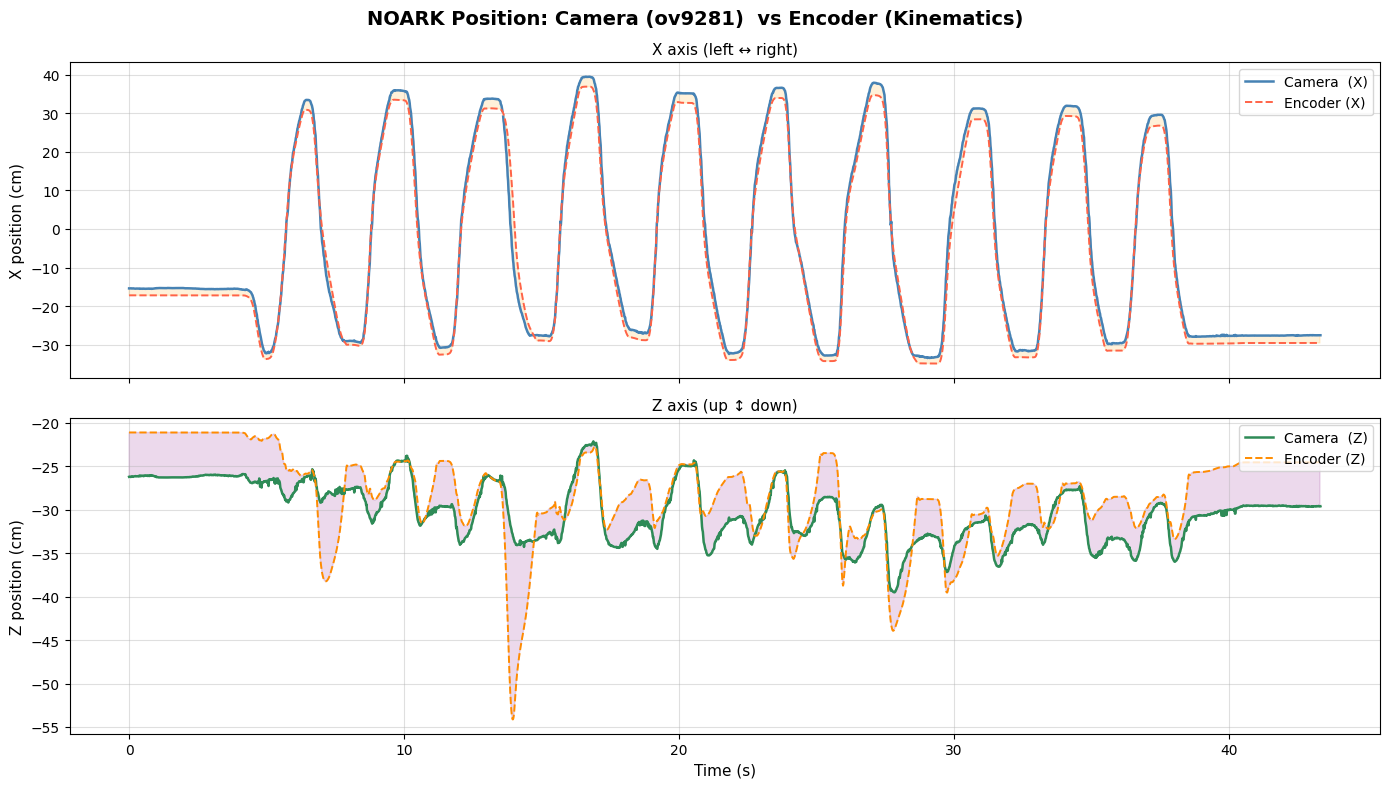

Saved: plot1_timeseries.png


In [88]:
# Cell 32
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Camera (ov9281)  vs Encoder (Kinematics)", fontsize=14, fontweight='bold')

t = merged["t_sec"]

ax = axes[0]
ax.plot(t, merged["x_cam_cm"], color="steelblue",  lw=1.8, label="Camera  (X)")
ax.plot(t, merged["x_enc_cm"], color="tomato",     lw=1.4, ls="--", label="Encoder (X)")
ax.fill_between(t, merged["x_cam_cm"], merged["x_enc_cm"], alpha=0.15, color="orange")
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
ax.plot(t, merged["z_cam_cm"], color="seagreen",   lw=1.8, label="Camera  (Z)")
ax.plot(t, merged["z_enc_cm"], color="darkorange", lw=1.4, ls="--", label="Encoder (Z)")
ax.fill_between(t, merged["z_cam_cm"], merged["z_enc_cm"], alpha=0.15, color="purple")
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot1_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_timeseries.png")

## Plot 2: 2D Trajectory + Error Box Plot — Camera vs Encoder

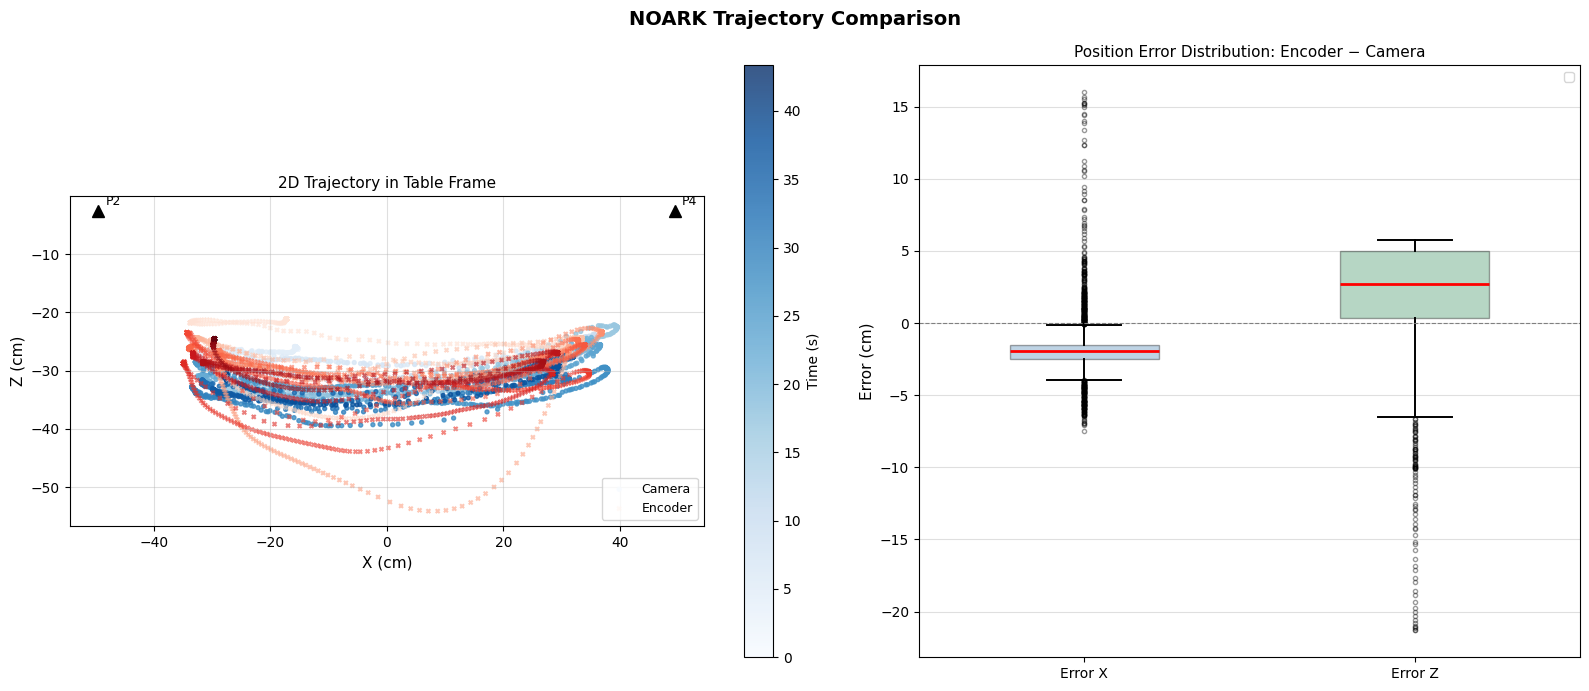

In [89]:
# Cell 33
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory Comparison", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory in X-Z table frame ─────────────────────────────
ax1 = fig.add_subplot(gs[0])
sc_cam = ax1.scatter(merged["x_cam_cm"], merged["z_cam_cm"],
                     c=merged["t_sec"], cmap="Blues", s=8, alpha=0.8, label="Camera")
sc_enc = ax1.scatter(merged["x_enc_cm"], merged["z_enc_cm"],
                     c=merged["t_sec"], cmap="Reds",  s=8, alpha=0.6, label="Encoder", marker="x")

for name, pt in [("P2", P2), ("P4", P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, "k^", ms=8)
    ax1.annotate(name, (pt[0]*100, pt[2]*100), textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.colorbar(sc_cam, ax=ax1, label="Time (s)")
ax1.set_xlabel("X (cm)", fontsize=11)
ax1.set_ylabel("Z (cm)", fontsize=11)
ax1.set_title("2D Trajectory in Table Frame", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_aspect("equal", adjustable="box")

# ── Right panel: Box plot of position errors ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])

error_data = [err_x_valid, err_z_valid]
labels      = ["Error X", "Error Z"]
colors      = ["steelblue", "seagreen"]

bp = ax2.boxplot(
    error_data,
    labels=labels,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.4),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.set_ylabel("Error (cm)", fontsize=11)
ax2.set_title("Position Error Distribution: Encoder − Camera", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis="y")

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot2_trajectory_error.png", dpi=150, bbox_inches="tight")
plt.show()

## ERROR STATISTICS — Mocap vs Camera

In [90]:
# Cell 34
# ── Mocap vs Camera errors ────────────────────────────────────────────────────
merged['err_mc_x_cm'] = merged['x_cam_cm'] - merged['x_mocap_cm']
merged['err_mc_z_cm'] = merged['z_cam_cm'] - merged['z_mocap_cm']

mask_mc = merged['err_mc_x_cm'].notna() & merged['err_mc_z_cm'].notna()

err_mc_x  = merged['err_mc_x_cm'][mask_mc].to_numpy()
err_mc_z  = merged['err_mc_z_cm'][mask_mc].to_numpy()

print(f"Valid frames : {mask_mc.sum()} / {len(merged)}")
print(f"x_mocap_cm valid : {merged['x_mocap_cm'].notna().sum()}")
print(f"x_cam_cm   valid : {merged['x_cam_cm'].notna().sum()}")
print(f"Both valid       : {(merged['x_mocap_cm'].notna() & merged['x_cam_cm'].notna()).sum()}")
print()

arr_stats(err_mc_x,  "err_mc_x_cm")
arr_stats(err_mc_z,  "err_mc_z_cm")
print()

print(f"Mean absolute error X : {np.mean(np.abs(err_mc_x)):.3f} cm")
print(f"Mean absolute error Z : {np.mean(np.abs(err_mc_z)):.3f} cm")
print(f"Max absolute error X  : {np.max(np.abs(err_mc_x)):.3f} cm")
print(f"Max absolute error Z  : {np.max(np.abs(err_mc_z)):.3f} cm")

Valid frames : 2811 / 2891
x_mocap_cm valid : 2813
x_cam_cm   valid : 2889
Both valid       : 2811

err_mc_x_cm      mean=2.000  std=0.563min=-0.762  max=5.582  RMSE=2.078  95th=2.945
err_mc_z_cm      mean=-4.024  std=1.778min=-6.206  max=0.009  RMSE=4.399  95th=-0.898

Mean absolute error X : 2.002 cm
Mean absolute error Z : 4.024 cm
Max absolute error X  : 5.582 cm
Max absolute error Z  : 6.206 cm


2D Trajectory + Error Box Plot: Mocap (GT) vs Camera

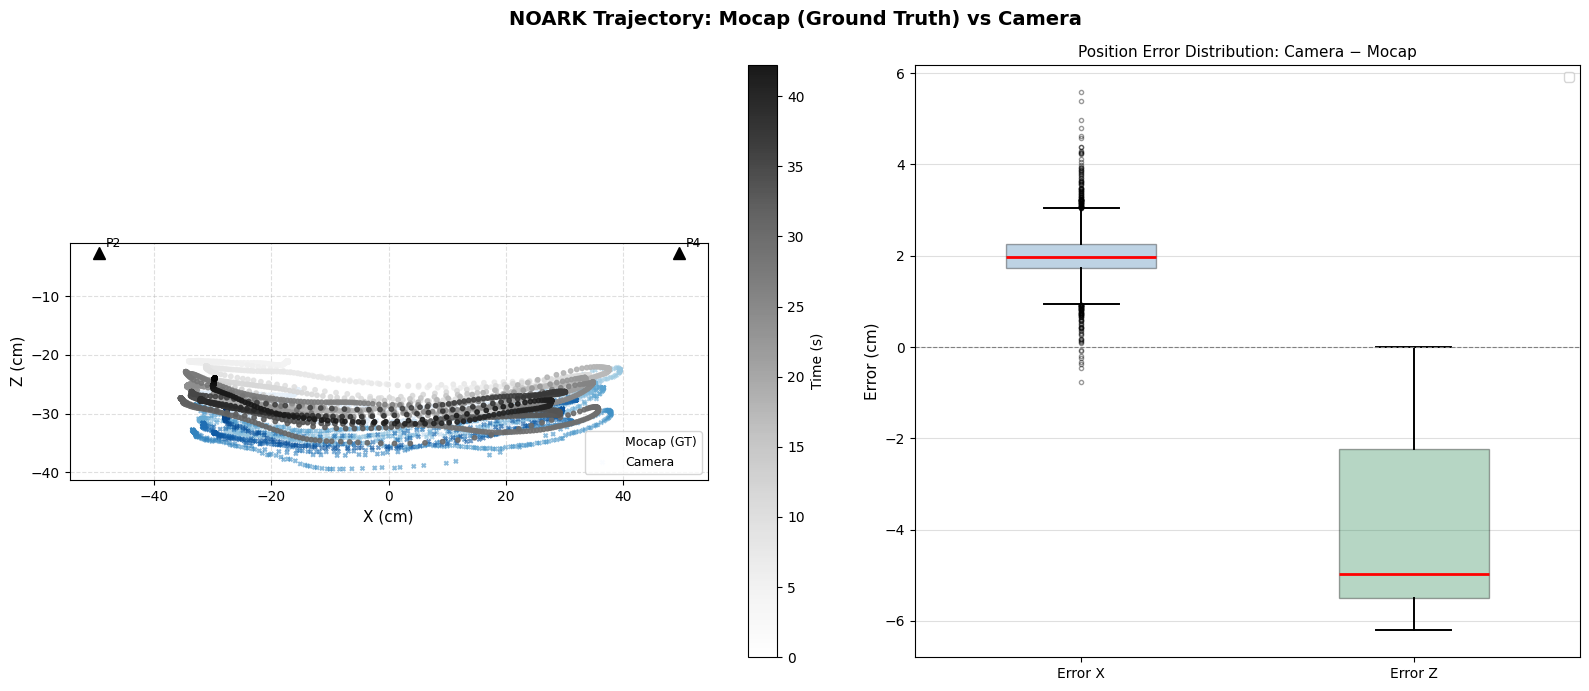

Saved: plot_mocap_vs_camera_2d.png


In [91]:
# Cell 35 — 2D Trajectory + Error Box Plot: Mocap (GT) vs Camera
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

sc_moc = ax1.scatter(merged['x_mocap_cm'], merged['z_mocap_cm'],
                     c=merged['t_sec'], cmap='Greys', s=10, alpha=0.9,
                     label='Mocap (GT)', zorder=4)
sc_cam = ax1.scatter(merged['x_cam_cm'], merged['z_cam_cm'],
                     c=merged['t_sec'], cmap='Blues', s=8, alpha=0.6,
                     label='Camera', marker='x', zorder=3)

# Pulley reference points from kinematics constants
for name, pt in [('P2', P2), ('P4', P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, 'k^', ms=8, zorder=5)
    ax1.annotate(name, (pt[0]*100, pt[2]*100),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.colorbar(sc_moc, ax=ax1, label='Time (s)')
ax1.set_xlabel('X (cm)', fontsize=11)
ax1.set_ylabel('Z (cm)', fontsize=11)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_aspect('equal', adjustable='box')

# ── Right panel: Box plot ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])


bp = ax2.boxplot(
    [err_mc_x, err_mc_z],
    labels=['Error X', 'Error Z'],
    patch_artist=True, notch=False, widths=0.45,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
)
for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'dimgray']):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_ylabel('Error (cm)', fontsize=11)
ax2.set_title('Position Error Distribution: Camera − Mocap', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(repo_root / 'vaideesh' / 'Analysis' / 'plot_mocap_vs_camera_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_camera_2d.png")

## ERROR STATISTICS — Mocap vs Encoder

In [92]:
# Cell 35
# ── Mocap vs Encoder errors ───────────────────────────────────────────────────
merged['err_me_x_cm']  = merged['x_enc_cm']  - merged['x_mocap_cm']
merged['err_me_z_cm']  = merged['z_enc_cm']  - merged['z_mocap_cm']

mask_me = (~merged['err_me_x_cm'].isna() &
           ~merged['err_me_z_cm'].isna() )

err_me_x   = merged['err_me_x_cm'][mask_me].to_numpy()
err_me_z   = merged['err_me_z_cm'][mask_me].to_numpy()

print(f"Valid frames for Mocap vs Encoder error: {mask_me.sum()} / {len(merged)}")
arr_stats(err_me_x,  "err_me_x_cm")
arr_stats(err_me_z,  "err_me_z_cm")

print(f"Mean absolute error X : {np.mean(np.abs(err_me_x)):.3f} cm")
print(f"Mean absolute error Z : {np.mean(np.abs(err_me_z)):.3f} cm")
print(f"Max absolute error X  : {np.max(np.abs(err_me_x)):.3f} cm")
print(f"Max absolute error Z  : {np.max(np.abs(err_me_z)):.3f} cm")

Valid frames for Mocap vs Encoder error: 2813 / 2891
err_me_x_cm      mean=0.303  std=2.217min=-4.435  max=18.914  RMSE=2.238  95th=3.727
err_me_z_cm      mean=-2.100  std=3.442min=-25.755  max=0.403  RMSE=4.032  95th=0.016
Mean absolute error X : 1.111 cm
Mean absolute error Z : 2.105 cm
Max absolute error X  : 18.914 cm
Max absolute error Z  : 25.755 cm


In [93]:
# # ── Visualise mocap frozen (dropout) frames ───────────────────────────────────
# mocap_z_diff = merged['z_mocap_cm'].diff().abs()
# mocap_x_diff = merged['x_mocap_cm'].diff().abs()
# dropout_mask = (mocap_z_diff == 0) & (mocap_x_diff == 0)

# print(f"Total frozen frames: {dropout_mask.sum()}")
# print(f"Time window: t = {merged.loc[dropout_mask, 't_sec'].min():.3f}s → {merged.loc[dropout_mask, 't_sec'].max():.3f}s")
# print()
# print("Frozen frames:")
# print(merged.loc[dropout_mask, ['t_sec', 'x_mocap_cm', 'z_mocap_cm',
#                                  'x_enc_cm', 'z_enc_cm',
#                                  'err_me_x_cm', 'err_me_z_cm']].to_string())

Trajectory + Error Box Plot: Mocap (GT) vs Encoder

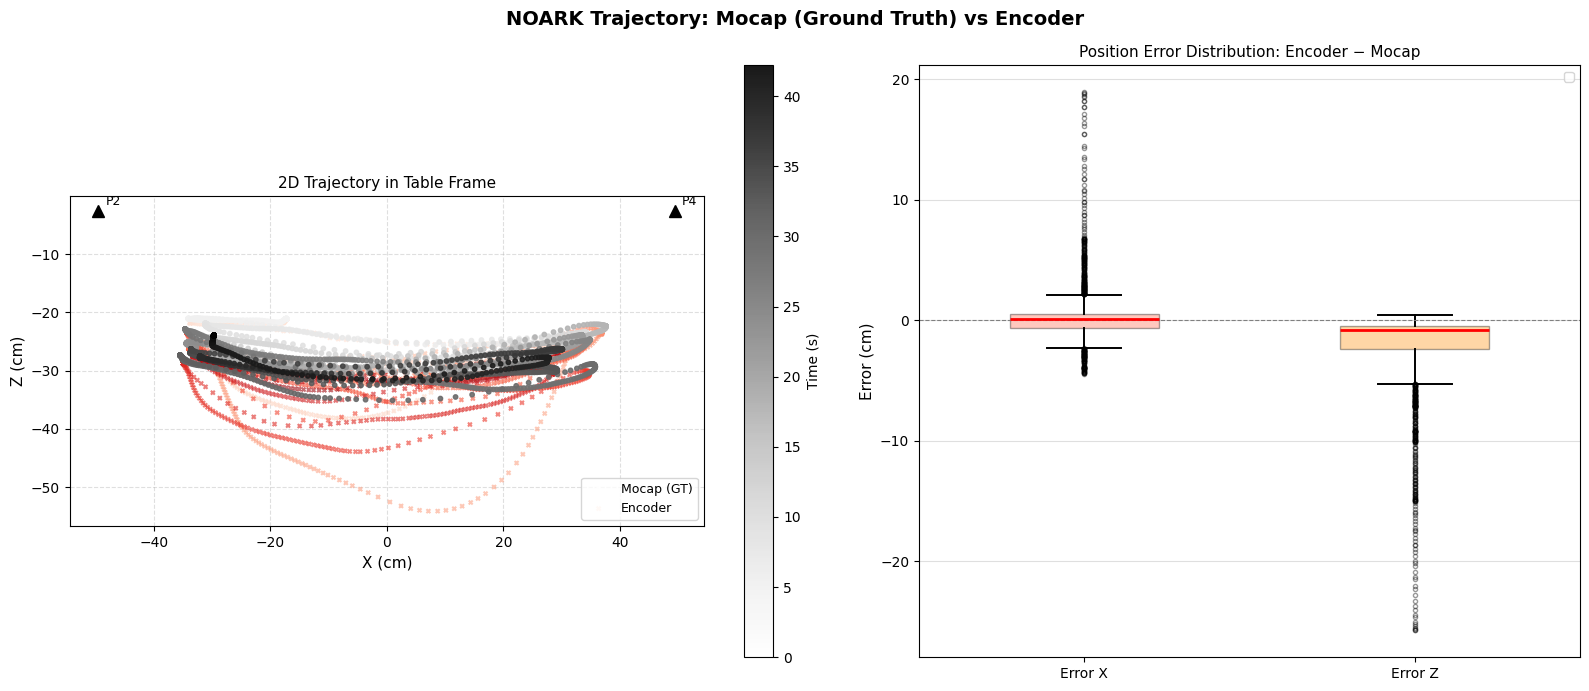

Saved: plot_mocap_vs_encoder_2d.png


In [94]:
# Cell 39 — 2D Trajectory + Error Box Plot: Mocap (GT) vs Encoder
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory: Mocap (Ground Truth) vs Encoder", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

sc_moc = ax1.scatter(merged['x_mocap_cm'], merged['z_mocap_cm'],
                     c=merged['t_sec'], cmap='Greys', s=10, alpha=0.9,
                     label='Mocap (GT)', zorder=4)
sc_enc = ax1.scatter(merged['x_enc_cm'], merged['z_enc_cm'],
                     c=merged['t_sec'], cmap='Reds', s=8, alpha=0.6,
                     label='Encoder', marker='x', zorder=3)

# Pulley reference points
for name, pt in [('P2', P2), ('P4', P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, 'k^', ms=8, zorder=5)
    ax1.annotate(name, (pt[0]*100, pt[2]*100),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.colorbar(sc_moc, ax=ax1, label='Time (s)')
ax1.set_xlabel('X (cm)', fontsize=11)
ax1.set_ylabel('Z (cm)', fontsize=11)
ax1.set_title('2D Trajectory in Table Frame', fontsize=11)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_aspect('equal', adjustable='box')

# ── Right panel: Box plot ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])


bp = ax2.boxplot(
    [err_me_x, err_me_z],
    labels=['Error X', 'Error Z'],
    patch_artist=True, notch=False, widths=0.45,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
)
for patch, color in zip(bp['boxes'], ['tomato', 'darkorange', 'dimgray']):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_ylabel('Error (cm)', fontsize=11)
ax2.set_title('Position Error Distribution: Encoder − Mocap', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(repo_root / 'vaideesh' / 'Analysis' / 'plot_mocap_vs_encoder_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_encoder_2d.png")

## Plot 3: Time-Series — Mocap (GT) vs Camera

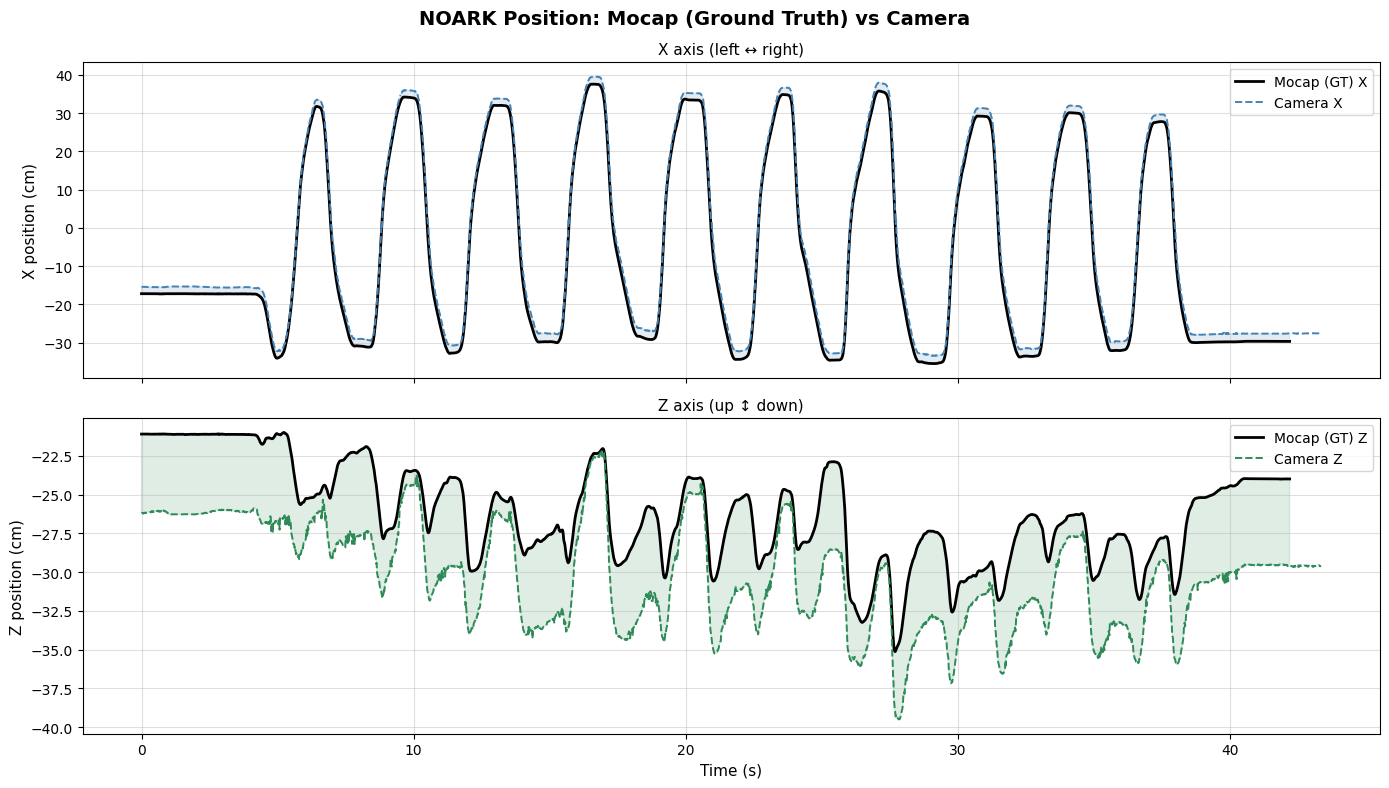

Saved: plot_mocap_vs_camera_timeseries.png


In [95]:
# Cell 36
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

t = merged['t_sec']

ax = axes[0]
ax.plot(t, merged['x_mocap_cm'], color='black',     lw=2.0, label='Mocap (GT) X')
ax.plot(t, merged['x_cam_cm'],   color='steelblue', lw=1.4, ls='--', label='Camera X')
ax.fill_between(t, merged['x_mocap_cm'], merged['x_cam_cm'], alpha=0.15, color='steelblue')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
ax.plot(t, merged['z_mocap_cm'], color='black',    lw=2.0, label='Mocap (GT) Z')
ax.plot(t, merged['z_cam_cm'],   color='seagreen', lw=1.4, ls='--', label='Camera Z')
ax.fill_between(t, merged['z_mocap_cm'], merged['z_cam_cm'], alpha=0.15, color='seagreen')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig('plot_mocap_vs_camera_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_camera_timeseries.png")

## Plot 4: Time-Series — Mocap (GT) vs Encoder

=== Mean Resultant Speed ===
  Mocap   : 31.756 cm/s  (std: 35.265)
  Encoder : 32.582 cm/s  (std: 33.721)
  Error (Enc - Mocap): +0.826 cm/s


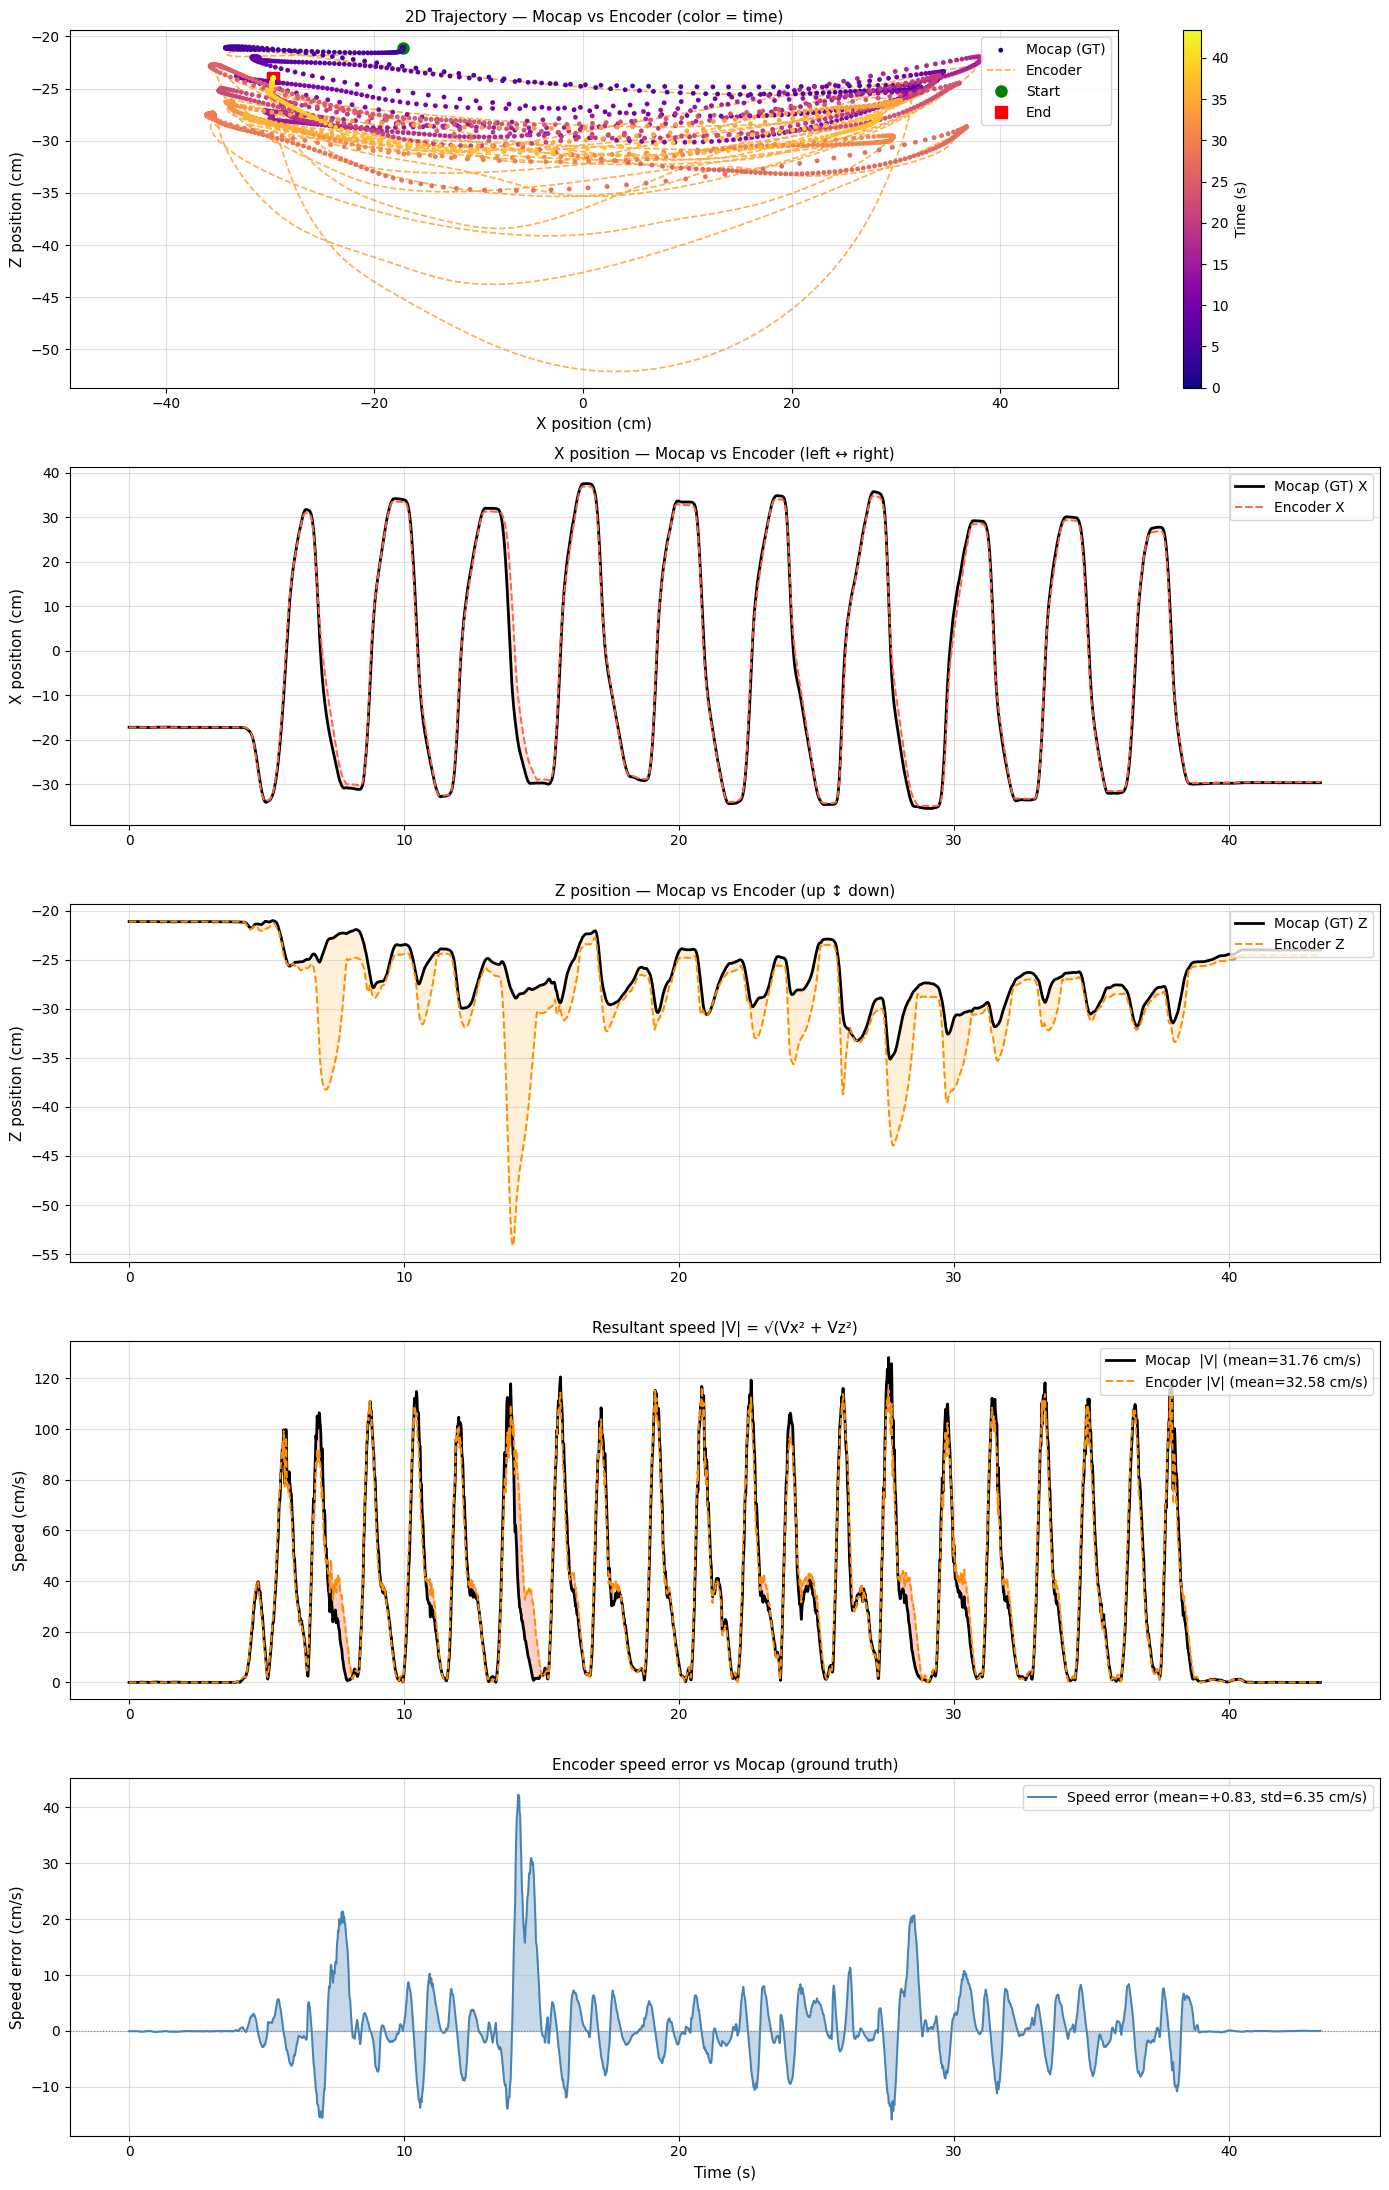

In [96]:
## Cell 38 — 5-panel: Trajectory + Position + Speed (fixed axes)
from scipy.signal import savgol_filter
import numpy as np

# --- Step 0: Clean ---
cols = ['x_mocap_cm', 'z_mocap_cm', 'x_enc_cm', 'z_enc_cm']
merged_clean = merged.copy()
for col in cols:
    merged_clean[col] = (merged_clean[col]
                         .replace([np.inf, -np.inf], np.nan)
                         .interpolate(method='linear')
                         .ffill().bfill())

t = merged_clean['t_sec'].values
n = len(merged_clean)

# --- Step 1: Smooth ---
window = min(51, n if n % 2 == 1 else n - 1)
poly   = 3

x_mocap_s = savgol_filter(merged_clean['x_mocap_cm'].values, window, poly)
z_mocap_s = savgol_filter(merged_clean['z_mocap_cm'].values, window, poly)
x_enc_s   = savgol_filter(merged_clean['x_enc_cm'].values,   window, poly)
z_enc_s   = savgol_filter(merged_clean['z_enc_cm'].values,   window, poly)

# --- Step 2: Resultant speed ---
vx_mocap = np.gradient(x_mocap_s, t)
vz_mocap = np.gradient(z_mocap_s, t)
vx_enc   = np.gradient(x_enc_s,   t)
vz_enc   = np.gradient(z_enc_s,   t)

speed_mocap = np.sqrt(vx_mocap**2 + vz_mocap**2)
speed_enc   = np.sqrt(vx_enc**2   + vz_enc**2)
speed_err   = speed_enc - speed_mocap

# --- Step 3: Print summary ---
print("=== Mean Resultant Speed ===")
print(f"  Mocap   : {speed_mocap.mean():.3f} cm/s  (std: {speed_mocap.std():.3f})")
print(f"  Encoder : {speed_enc.mean():.3f} cm/s  (std: {speed_enc.std():.3f})")
print(f"  Error (Enc - Mocap): {speed_err.mean():+.3f} cm/s")

# --- Step 4: 5-panel figure ---
# Panel 1 is spatial (X vs Z), panels 2-5 are time-series — DO NOT sharex all together
fig, axes = plt.subplots(5, 1, figsize=(14, 22))
# fig.suptitle("NOARK: Trajectory, Position & Resultant Speed", fontsize=14, fontweight='bold')

t_s = merged_clean['t_sec']

# Panel 1: 2D trajectory — spatial axes, independent
ax = axes[0]
sc = ax.scatter(x_mocap_s, z_mocap_s, c=t, cmap='plasma', s=6, label='Mocap (GT)', zorder=3)
ax.plot(x_enc_s, z_enc_s, color='darkorange', lw=1.2, ls='--', alpha=0.7, label='Encoder')
ax.plot(x_mocap_s[0],  z_mocap_s[0],  'go', ms=8, label='Start')
ax.plot(x_mocap_s[-1], z_mocap_s[-1], 'rs', ms=8, label='End')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time (s)", fontsize=10)
ax.set_xlabel("X position (cm)", fontsize=11)
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("2D Trajectory — Mocap vs Encoder (color = time)", fontsize=11)
ax.set_aspect('equal', adjustable='datalim')

# Panel 2: X position — time axis
ax = axes[1]
ax.plot(t_s, merged_clean['x_mocap_cm'], color='black',  lw=2.0, label='Mocap (GT) X')
ax.plot(t_s, merged_clean['x_enc_cm'],   color='tomato', lw=1.4, ls='--', label='Encoder X')
ax.fill_between(t_s, merged_clean['x_mocap_cm'], merged_clean['x_enc_cm'], alpha=0.15, color='tomato')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X position — Mocap vs Encoder (left ↔ right)", fontsize=11)

# Panel 3: Z position — time axis
ax = axes[2]
ax.plot(t_s, merged_clean['z_mocap_cm'], color='black',      lw=2.0, label='Mocap (GT) Z')
ax.plot(t_s, merged_clean['z_enc_cm'],   color='darkorange', lw=1.4, ls='--', label='Encoder Z')
ax.fill_between(t_s, merged_clean['z_mocap_cm'], merged_clean['z_enc_cm'], alpha=0.15, color='orange')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z position — Mocap vs Encoder (up ↕ down)", fontsize=11)

# Panel 4: Resultant speed — time axis
ax = axes[3]
ax.plot(t_s, speed_mocap, color='black',      lw=2.0,
        label=f'Mocap  |V| (mean={speed_mocap.mean():.2f} cm/s)')
ax.plot(t_s, speed_enc,   color='darkorange', lw=1.4, ls='--',
        label=f'Encoder |V| (mean={speed_enc.mean():.2f} cm/s)')
ax.fill_between(t_s, speed_mocap, speed_enc, alpha=0.3, color='tomato')
ax.set_ylabel("Speed (cm/s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Resultant speed |V| = √(Vx² + Vz²)", fontsize=11)

# Panel 5: Speed error — time axis
ax = axes[4]
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.plot(t_s, speed_err, color='steelblue', lw=1.4,
        label=f'Speed error (mean={speed_err.mean():+.2f}, std={speed_err.std():.2f} cm/s)')
ax.fill_between(t_s, speed_err, 0, alpha=0.3, color='steelblue')
ax.set_ylabel("Speed error (cm/s)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Encoder speed error vs Mocap (ground truth)", fontsize=11)

# Share time axis across panels 2-5 only
for ax in axes[2:]:
    ax.sharex(axes[1])

plt.tight_layout()
plt.savefig('plot_trajectory_position_speed_5panel.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: plot_trajectory_position_speed_5panel.png")

## Plot 5: Error Distribution Box Plots — Mocap vs Camera & Mocap vs Encoder

> **FIX (Bug 5):** Loop variables renamed to `ex`, `ez`, `e2d` to avoid shadowing the outer `err_x`, `err_z`, `err_2d` arrays from the Camera vs Encoder block.

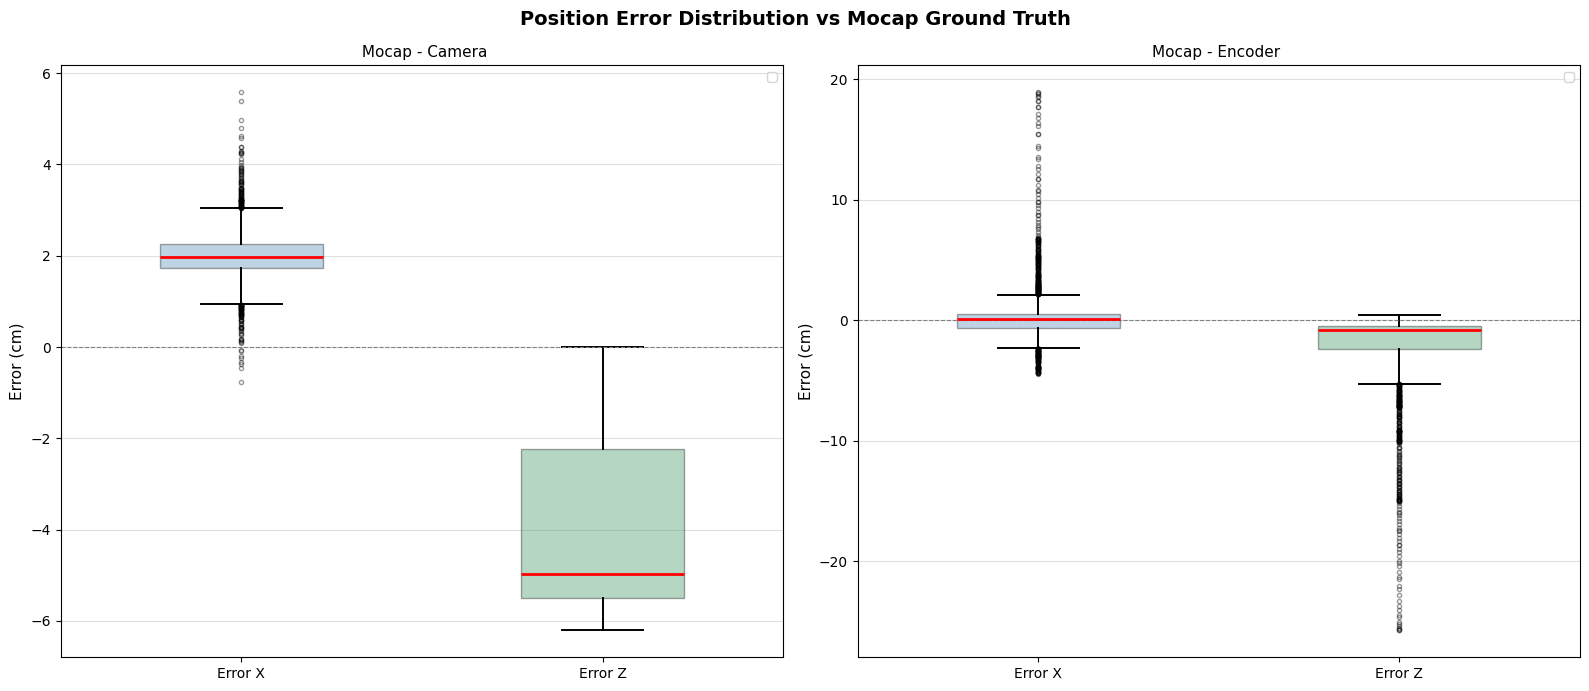

In [97]:
# Cell 38
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Position Error Distribution vs Mocap Ground Truth", fontsize=14, fontweight='bold')

# FIX (Bug 5): loop variables renamed ex/ez/e2d — no longer shadows outer err_x/err_z/err_2d
for ax, (ex, ez, title) in zip(axes, [
    (err_mc_x, err_mc_z, " Mocap - Camera"),
    (err_me_x, err_me_z, "Mocap - Encoder "),
]):
    bp = ax.boxplot(
        [ex, ez],
        labels=["Error X", "Error Z"],
        patch_artist=True, notch=False, widths=0.45,
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'black']):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    # rmse = np.sqrt((e2d**2).mean())
    # ax.axhline(rmse, color='red', lw=1.2, ls=':', label=f'RMSE 2D = {rmse:.2f} cm')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_ylabel("Error (cm)", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('plot_mocap_error_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:
# ── Compare NOARK position before and after tframe conversion ─────────────────
noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
df_raw = rb_dfs[noark_key].copy()
df_tf  = tframe_dfs['noark_in_tframe'].copy()
_nm    = tframe_dfs['_noark_marker']

xcol_raw = f'{noark_key}_marker_m{_nm}_x'
ycol_raw = f'{noark_key}_marker_m{_nm}_y'
zcol_raw = f'{noark_key}_marker_m{_nm}_z'

xcol_tf  = f'noark_m{_nm}_tf_x_m'
zcol_tf  = f'noark_m{_nm}_tf_z_m'

print(f"NOARK marker m{_nm} — RAW mocap frame (metres) vs TABLE frame (metres)")
print(f"{'Frame':>6}  {'Raw X':>10}  {'Raw Z':>10}  {'TF X':>10}  {'TF Z':>10}")
print('-' * 52)
for i in range(min(10, len(df_raw))):
    rx = df_raw.loc[i, xcol_raw]
    rz = df_raw.loc[i, zcol_raw]
    tx = df_tf.loc[i, xcol_tf]
    tz = df_tf.loc[i, zcol_tf]
    print(f"{i:>6}  {rx:>10.4f}  {rz:>10.4f}  {tx:>10.4f}  {tz:>10.4f}")

print(f"\nSummary statistics:")
print(f"{'':12}  {'Raw X':>10}  {'Raw Z':>10}  {'TF X':>10}  {'TF Z':>10}")
print(f"{'mean':12}  {df_raw[xcol_raw].mean():>10.4f}  {df_raw[zcol_raw].mean():>10.4f}  {df_tf[xcol_tf].mean():>10.4f}  {df_tf[zcol_tf].mean():>10.4f}")
print(f"{'min':12}  {df_raw[xcol_raw].min():>10.4f}  {df_raw[zcol_raw].min():>10.4f}  {df_tf[xcol_tf].min():>10.4f}  {df_tf[zcol_tf].min():>10.4f}")
print(f"{'max':12}  {df_raw[xcol_raw].max():>10.4f}  {df_raw[zcol_raw].max():>10.4f}  {df_tf[xcol_tf].max():>10.4f}  {df_tf[zcol_tf].max():>10.4f}")

NOARK marker m3 — RAW mocap frame (metres) vs TABLE frame (metres)
 Frame       Raw X       Raw Z        TF X        TF Z
----------------------------------------------------
     0     -0.0806      0.4340     -0.1722     -0.2110
     1     -0.0806      0.4340     -0.1722     -0.2110
     2     -0.0806      0.4340     -0.1722     -0.2110
     3     -0.0806      0.4340     -0.1722     -0.2110
     4     -0.0806      0.4340     -0.1722     -0.2111
     5     -0.0806      0.4340     -0.1722     -0.2110
     6         nan         nan         nan         nan
     7     -0.0806      0.4340     -0.1722     -0.2110
     8     -0.0806      0.4340     -0.1722     -0.2110
     9     -0.0806      0.4340     -0.1722     -0.2110

Summary statistics:
                   Raw X       Raw Z        TF X        TF Z
mean             -0.1909      0.4846     -0.0621     -0.2621
min              -0.6286      0.4336     -0.3550     -0.3513
max               0.1019      0.5735      0.3758     -0.2100


Sanity check for triangle inequality violation

In [99]:
# # Compare enc1/enc2 absolute values across full recording vs t=28-34s window
# print("=== Full recording ===")
# print(f"enc1 range: {enc_s['enc1'].min():.2f} → {enc_s['enc1'].max():.2f} deg")
# print(f"enc2 range: {enc_s['enc2'].min():.2f} → {enc_s['enc2'].max():.2f} deg")

# mask_drop = (enc_s['t_sec'] >= 28.0) & (enc_s['t_sec'] <= 34.0)
# print("\n=== Dropout window t=28-34s ===")
# print(f"enc1 range: {enc_s.loc[mask_drop, 'enc1'].min():.2f} → {enc_s.loc[mask_drop, 'enc1'].max():.2f} deg")
# print(f"enc2 range: {enc_s.loc[mask_drop, 'enc2'].min():.2f} → {enc_s.loc[mask_drop, 'enc2'].max():.2f} deg")

# # Also check cable lengths in that window
# mask_drop_enc = (enc_s['t_sec'] >= 28.0) & (enc_s['t_sec'] <= 34.0)
# enc_drop = enc_s[mask_drop_enc]
# L_L = P2_to_NOARK_init_mocap + r_ML * np.deg2rad(enc_drop['enc1'].values)
# L_R = P4_to_NOARK_init_mocap - r_MR * np.deg2rad(enc_drop['enc2'].values)

# d = np.sqrt((P4_mocap[0]-P2_mocap[0])**2 + (P4_mocap[2]-P2_mocap[2])**2)

# print(f"\nP2-P4 distance       : {d*100:.3f} cm")
# print(f"L_free_L range       : {L_L.min()*100:.3f} → {L_L.max()*100:.3f} cm")
# print(f"L_free_R range       : {L_R.min()*100:.3f} → {L_R.max()*100:.3f} cm")
# print(f"L_free_L + L_free_R  : {(L_L+L_R).min()*100:.3f} → {(L_L+L_R).max()*100:.3f} cm")
# print(f"|L_free_L - L_free_R|: {np.abs(L_L-L_R).min()*100:.3f} → {np.abs(L_L-L_R).max()*100:.3f} cm")
# print(f"Frames where |L_L-L_R| > d: {(np.abs(L_L-L_R) > d).sum()}  ← triangle inequality violation")

In [100]:
# print("=== BEFORE shift ===")
# print(f"MAE X : {np.mean(np.abs(err_x_before[mask_before])):.3f} cm")
# print(f"MAE Z : {np.mean(np.abs(err_z_before[mask_before])):.3f} cm")
# print(f"RMSE X: {np.sqrt(np.mean(err_x_before[mask_before]**2)):.3f} cm")
# print(f"RMSE Z: {np.sqrt(np.mean(err_z_before[mask_before]**2)):.3f} cm")

In [101]:
# # ── Combined plot: Z error vs pulley proximity ────────────────────────────────
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# # ── Plot 1: Z position mocap vs encoder ──────────────────────────────────────
# ax1.plot(merged['t_sec'], merged['z_mocap_cm'], 'k-',  lw=1.5, label='Mocap (GT) Z')
# ax1.plot(merged['t_sec'], merged['z_enc_cm'],   color='orange', ls='--', lw=1.2, label='Encoder Z')
# ax1.set_ylabel('Z position (cm)')
# ax1.set_title('Z position — Mocap vs Encoder')
# ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.4)

# # ── Plot 2: Z error ───────────────────────────────────────────────────────────
# ax2.plot(merged['t_sec'], merged['err_me_z_cm'], color='red', lw=1.2, label='Z error (enc - mocap)')
# ax2.axhline(0, color='black', lw=0.8, ls='--')
# ax2.set_ylabel('Z error (cm)')
# ax2.set_title('Encoder Z error')
# ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.4)

# # ── Plot 3: Distance to P2 and P4 ────────────────────────────────────────────
# ax3.plot(t_sec, dist_P2, color='steelblue', lw=1.2, label='Distance to P2 (left)')
# ax3.plot(t_sec, dist_P4, color='seagreen',  lw=1.2, label='Distance to P4 (right)')
# ax3.axhline(35, color='red', ls='--', lw=1, label='35 cm threshold')

# # shade close-approach windows on all subplots
# close_windows = [
#     (6.03,  6.73,  'P2'),
#     (12.80, 13.48, 'P2'),
#     (14.17, 15.08, 'P4'),
#     (4.38,  5.36,  'P4'),
#     (2.72,  3.83,  'P2'),
# ]
# for t_s, t_e, label in close_windows:
#     color = 'steelblue' if label == 'P2' else 'seagreen'
#     for ax in [ax1, ax2, ax3]:
#         ax.axvspan(t_s, t_e, alpha=0.15, color=color)

# ax3.set_ylabel('Distance (cm)')
# ax3.set_xlabel('Time (s)')
# ax3.set_title('NOARK distance to P2 and P4')
# ax3.legend(loc='upper right'); ax3.grid(True, alpha=0.4)

# plt.tight_layout()
# plt.savefig('z_error_vs_pulley_proximity.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── Print correlation ─────────────────────────────────────────────────────────
# print("Close-approach windows vs max Z error:")
# print(f"{'Window':>20}  {'Pulley':>6}  {'Max |Z error| in window':>25}")
# for t_s, t_e, label in close_windows:
#     w = (merged['t_sec'] >= t_s) & (merged['t_sec'] <= t_e)
#     max_err = merged.loc[w, 'err_me_z_cm'].abs().max()
#     print(f"  t={t_s:.2f}–{t_e:.2f}s  {label:>6}  {max_err:>10.3f} cm")

In [102]:
print("cam_df columns:", cam_df.columns.tolist())
print("cam x range:", cam_df['x_cam'].min(), "→", cam_df['x_cam'].max())
print("cam z range:", cam_df['z_cam'].min(), "→", cam_df['z_cam'].max())
print("enc x range:", enc_s['x_enc'].min(), "→", enc_s['x_enc'].max())
print("enc z range:", enc_s['z_enc'].min(), "→", enc_s['z_enc'].max())

cam_df columns: ['timestamp', 'sync_pin', 'tvec_12_x', 'tvec_12_y', 'tvec_12_z', 'tvec_14_x', 'tvec_14_y', 'tvec_14_z', 'tvec_20_x', 'tvec_20_y', 'tvec_20_z', 'rvec_12_x', 'rvec_12_y', 'rvec_12_z', 'rvec_14_x', 'rvec_14_y', 'rvec_14_z', 'rvec_20_x', 'rvec_20_y', 'rvec_20_z', 'x_cam', 'y_cam', 'z_cam', 't_sec']
cam x range: -0.33501737148469557 → 0.3953158148903304
cam z range: -0.3949272614535896 → -0.22126916477329903
enc x range: -0.349357776606972 → 0.3694331296678601
enc z range: -0.5414117941616013 → -0.21101818730159538
